In [107]:
# Importación de librerías necesarias (TP1 y TP2)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
import os
import pyarrow
import pyarrow.parquet as pq
#import missingno
import openpyxl
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
from plotly.subplots import make_subplots
import plotly.graph_objects as go

#Librerías para TP3

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")

In [108]:
# Construcción del path relativo al archivo (para que corra en cualquier entorno)
def get_data_path(filename):
    base_dir = os.path.dirname(os.getcwd())
    return os.path.join(base_dir, 'data', filename)


filename = 'final_uncured_df.csv'


file_path = get_data_path(filename)
raw_df = pd.read_csv(file_path)
raw_df.drop(columns=['Unnamed: 0'], inplace=True)  #eliminamos la columna innecesaria

#vemos la estructura del dataset
print(f"Dimensiones: {raw_df.shape}")
print("\nTipos de datos:")
display(raw_df.dtypes)
display(raw_df.head())
# print("\nValores nulos:")
# print(raw_df.isnull().sum().head(52))

Dimensiones: (21060, 16)

Tipos de datos:


cliente               int64
produc               object
mes                  object
ventas_totales      float64
unidades_totales    float64
dias_con_venta      float64
dias_mes            float64
frecuencia_pct      float64
descrip              object
depo                float64
tipo_negocio        float64
lista_precios       float64
condi_venta          object
vende               float64
linea_nume          float64
sin_venta              bool
dtype: object

,cliente,produc,mes,ventas_totales,unidades_totales,dias_con_venta,dias_mes,frecuencia_pct,descrip,depo,tipo_negocio,lista_precios,condi_venta,vende,linea_nume,sin_venta
0,4627,000-000-2001,2022-01,22.727986,12.0,1.0,31.0,0.032258,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False
1,4627,000-000-2001,2022-02,48.113674,24.0,2.0,28.0,0.071429,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False
2,4627,000-000-2001,2022-03,80.252343,36.0,3.0,31.0,0.096774,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False
3,4627,000-000-2001,2022-04,30.300890,12.0,1.0,30.0,0.033333,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False
4,4627,000-000-2001,2022-05,68.505820,24.0,2.0,31.0,0.064516,mogul tiburoncitos x 12 uds.,1.0,1.0,2.0,00,1.0,3.0,False


## Conclusiones iniciales

- Tenemos **{feat.shape[0]} clientes** con información agregada mensual.
- Variables incluidas en el clustering:
  - Ventas totales, unidades totales, ticket promedio.
  - Diversidad de productos distintos y meses presentes.
  - Variables de frecuencia y días promedio con venta.
- Estas variables capturan **volumen, intensidad, estabilidad y diversidad** del comportamiento de compra.
- Se espera que los clusters reflejen distintos “perfiles de cliente” en base a estas dimensiones.


## 1) Clusterización


In [109]:
# 2) Tipos y columnas base (TP2 ya dejó nivel mensual y columnas agregadas)
# PDV ≡ cliente | SKU ≡ produc | tiempo ≡ mes (formato 'YYYY-MM')

df = raw_df.copy()

# Asegurar tipos:
df['mes'] = pd.to_datetime(df['mes'] + "-01")  # pasar a timestamp de inicio de mes
num_cols = ['ventas_totales','unidades_totales','dias_con_venta','dias_mes','frecuencia_pct','vende','depo','tipo_negocio','lista_precios','linea_nume']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Chequeo rápido
print(df[['cliente','produc','mes','ventas_totales','unidades_totales','dias_con_venta','frecuencia_pct']].head(3))


   cliente        produc        mes  ventas_totales  unidades_totales  \
0     4627  000-000-2001 2022-01-01       22.727986              12.0   
1     4627  000-000-2001 2022-02-01       48.113674              24.0   
2     4627  000-000-2001 2022-03-01       80.252343              36.0   

   dias_con_venta  frecuencia_pct  
0             1.0        0.032258  
1             2.0        0.071429  
2             3.0        0.096774  


In [110]:
# 3) Construcción de features por PDV (cliente)

#  - ventas_totales (sum)
#  - unidades_totales (sum)
#  - productos_distintos (nunique por 'produc')
#  - meses_presentes (nunique por 'mes')
#  - frecuencia_media (mean de 'frecuencia_pct')
#  - dias_promedio (mean de 'dias_con_venta')
#  - ticket_promedio = ventas_totales / unidades_totales

group_cols = ['cliente']
feat = (
    df.groupby(group_cols)
      .agg(
          ventas_totales=('ventas_totales','sum'),
          unidades_totales=('unidades_totales','sum'),
          productos_distintos=('produc','nunique'),
          meses_presentes=('mes','nunique'),
          frecuencia_media=('frecuencia_pct','mean'),
          dias_promedio=('dias_con_venta','mean')
      )
      .reset_index()
)

feat['ticket_promedio'] = feat['ventas_totales'] / feat['unidades_totales'].replace(0, np.nan)
feat = feat.fillna(0.0)

print("Features shape:", feat.shape)
feat.head()


Features shape: (139, 8)


,cliente,ventas_totales,unidades_totales,productos_distintos,meses_presentes,frecuencia_media,dias_promedio,ticket_promedio
0,296,95643.703234,2068.0,4,30,0.060190,1.831579,46.249373
1,526,623872.255152,89749.0,19,30,0.055281,1.681917,6.951300
2,606,6143.817552,136.0,1,30,0.041653,1.272727,45.175129
3,710,52937.104982,2016.0,1,30,0.049353,1.500000,26.258485
4,763,20099.061557,648.0,1,30,0.041448,1.260870,31.017070


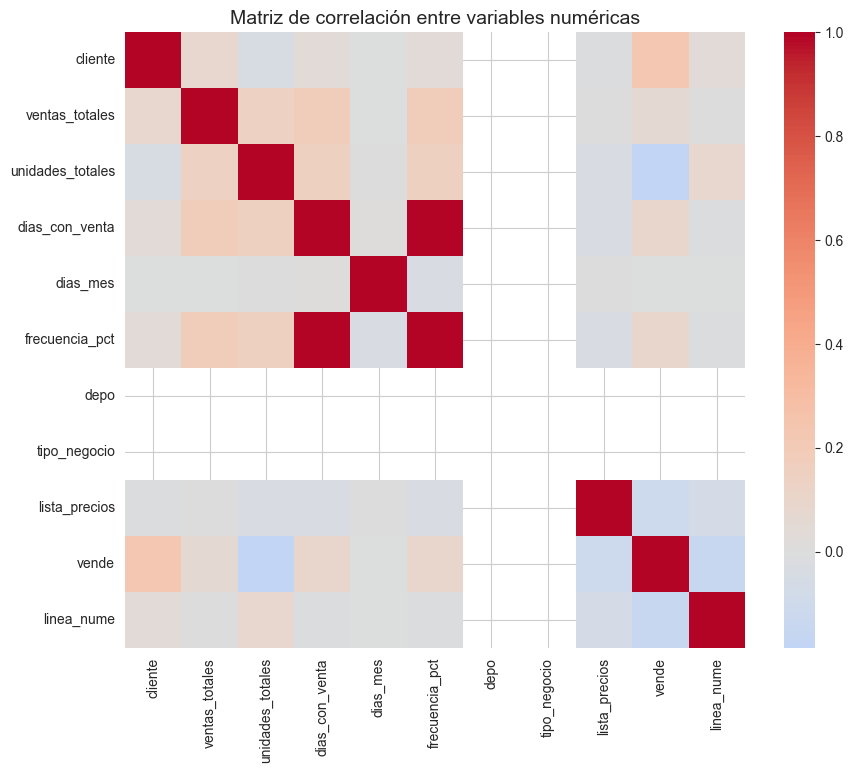

Pares de variables con correlación alta (>0.85):


,var1,var2,corr
22,dias_con_venta,frecuencia_pct,0.998214


In [111]:
# Exploración de correlaciones 

# Seleccionamos solo las variables numéricas candidatas al clustering
vars_cluster = df.select_dtypes(include=["float64", "int64"])

# calculamos la matriz
corr = vars_cluster.corr(method="pearson")

# Heatmap de correlación
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre variables numéricas", fontsize=14)
plt.show()

#mostrar pares muy correlacionados (>0.85)
umbral = 0.85
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["var1", "var2", "corr"]
print("Pares de variables con correlación alta (>0.85):")
display(corr_pairs[corr_pairs["corr"].abs() > umbral])


Al utilizar la técnica PCA para determinar los componentes principales de la clsuterización, no eliminamos las variables con alta correlación

## Técnica Kmedias

In [112]:
RANDOM_STATE = 15
# Escalado + PCA (solo para representación; el clustering puede correr en Xz)

feat_vars = [
    "ventas_totales", "unidades_totales", "productos_distintos",
    "meses_presentes", "frecuencia_media", "dias_promedio", "ticket_promedio"
]

X = feat[feat_vars].values

# Estandarización
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

# PCA (primeras 4 componentes para visualización y análisis)
pca = PCA(n_components=4, random_state=RANDOM_STATE)
Xp = pca.fit_transform(Xz)

# Guardamos para trazabilidad
pca_var = pca.explained_variance_ratio_.cumsum()

print("Shape X (raw):", X.shape)
print("Shape Xz (scaled):", Xz.shape)
print("Shape Xp (PCA):", Xp.shape)
print("Var. explicada acumulada (PCA):", pca_var)

# (Opcional) DataFrames auxiliares para inspección tabular en celdas separadas
Xz_df = pd.DataFrame(Xz, columns=[f"z_{c}" for c in feat_vars]).assign(cliente=feat["cliente"].values)
Xp_df = pd.DataFrame(Xp, columns=[f"PC{i+1}" for i in range(Xp.shape[1])]).assign(cliente=feat["cliente"].values)


Shape X (raw): (139, 7)
Shape Xz (scaled): (139, 7)
Shape Xp (PCA): (139, 4)
Var. explicada acumulada (PCA): [0.46948789 0.76212046 0.92073945 0.97919247]


Con las primeras 4 componentes principales tenemos el 97% de la varianza explicada así que trabajaremos con estas

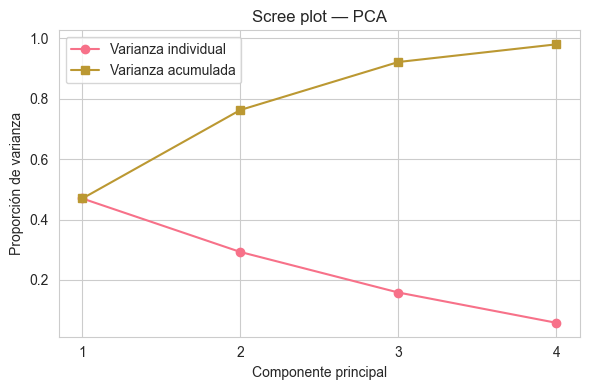

In [113]:
# Scree plot de la varianza explicada
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_,
         marker="o", label="Varianza individual")
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca_var, marker="s", label="Varianza acumulada")
plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))
plt.xlabel("Componente principal")
plt.ylabel("Proporción de varianza")
plt.title("Scree plot — PCA")
plt.legend()
plt.tight_layout()
plt.show()


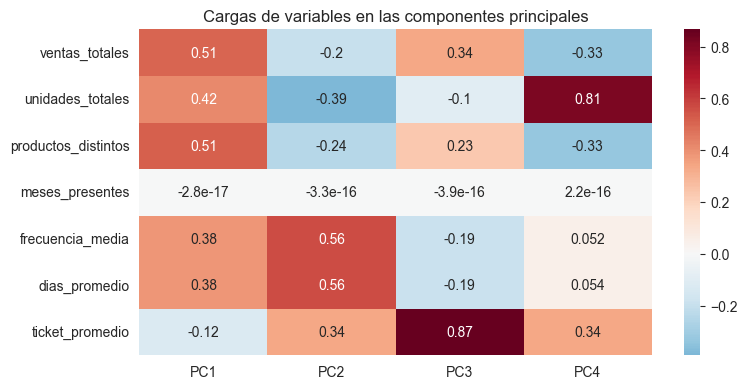

,PC1,PC2,PC3,PC4
ventas_totales,5.068643e-01,-1.986006e-01,3.377627e-01,-3.322146e-01
unidades_totales,4.161219e-01,-3.921891e-01,-1.019062e-01,8.137041e-01
productos_distintos,5.139997e-01,-2.400821e-01,2.347011e-01,-3.288703e-01
meses_presentes,-2.775558e-17,-3.330669e-16,-3.885781e-16,2.220446e-16
frecuencia_media,3.815393e-01,5.625407e-01,-1.870631e-01,5.181822e-02
dias_promedio,3.807637e-01,5.632936e-01,-1.873196e-01,5.413499e-02
ticket_promedio,-1.232161e-01,3.396387e-01,8.662365e-01,3.372650e-01


In [114]:
# Loadings (cargas de las variables en cada PC)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=feat_vars
)

plt.figure(figsize=(8,4))
sns.heatmap(loadings, annot=True, cmap="RdBu_r", center=0)
plt.title("Cargas de variables en las componentes principales")
plt.tight_layout()
plt.show()

loadings


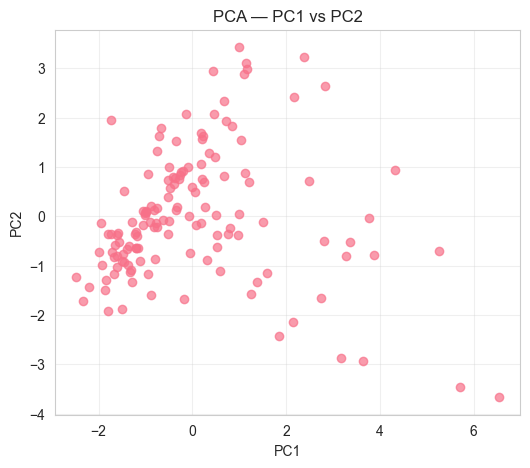

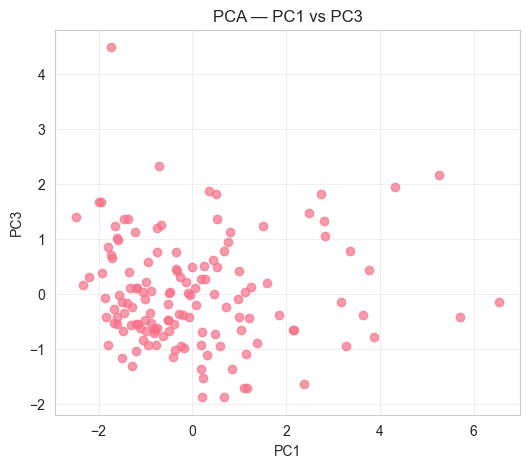

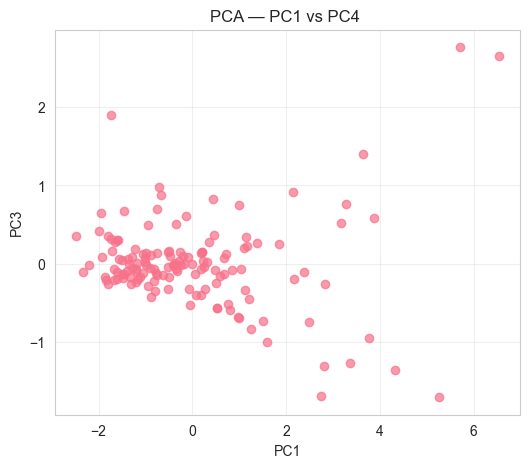

In [115]:
# Scatter PCA (PC1 vs PC2 y PC1 vs PC3)
plt.figure(figsize=(6,5))
plt.scatter(Xp[:,0], Xp[:,1], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA — PC1 vs PC2")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Xp[:,0], Xp[:,2], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.title("PCA — PC1 vs PC3")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Xp[:,0], Xp[:,3], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.title("PCA — PC1 vs PC4 ")
plt.grid(True, alpha=0.3)
plt.show()


Aplicamos DBSCAN para encontrar grupos de puntos que están densamente conectados

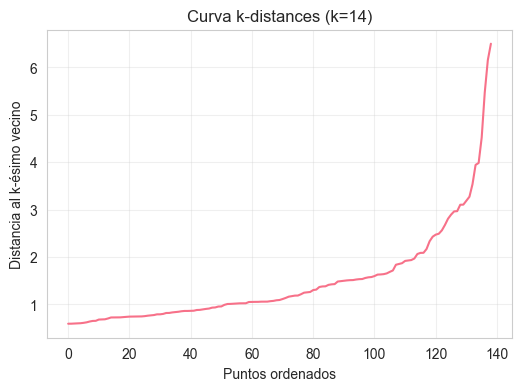

Distancia k-ésimo vecino (k=14): min=0.590, max=6.501, media=1.487, mediana=1.091


In [116]:
# Curva k-distances para estimar eps de DBSCAN
from sklearn.neighbors import NearestNeighbors

# min_samples ≈ 2*dimensión
k = Xz.shape[1] * 2

nbrs = NearestNeighbors(n_neighbors=k)
nbrs_fit = nbrs.fit(Xz)
distances, indices = nbrs_fit.kneighbors(Xz)

# Tomamos la distancia al k-ésimo vecino
kdist = np.sort(distances[:, -1])

plt.figure(figsize=(6,4))
plt.plot(kdist)
plt.title(f"Curva k-distances (k={k})")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia al k-ésimo vecino")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Distancia k-ésimo vecino (k={k}): min={kdist.min():.3f}, max={kdist.max():.3f}, media={kdist.mean():.3f}, mediana={np.median(kdist):.3f}")


Conclusión:

- En la parte baja la distancia crece lentamente → puntos en regiones densas.
- En cierto punto la curva se dispara (codo, puntos mas aislados).
- El codo se ve cerca de distancia 2–3. Eso sería un candidato para eps.

Con eso, correremos DBSCAN con parámetros: eps= 2–3 y min_samples=14.

In [117]:
# Exploración de eps candidatos para DBSCAN
from sklearn.cluster import DBSCAN
#pcentiles
candidatos = [80, 85, 88, 90, 92, 95]
res_eps = []

for q in candidatos:
    eps_i = float(np.percentile(kdist, q))
    labels = DBSCAN(eps=eps_i, min_samples=k, metric="euclidean").fit_predict(Xz)
    ruido = (labels == -1).mean() * 100
    n_clusters = len(np.unique(labels[labels != -1]))
    res_eps.append({
        "percentil": q,
        "eps": round(eps_i, 3),
        "clusters": n_clusters,
        "ruido_pct": round(ruido, 2)
    })

pd.DataFrame(res_eps)


,percentil,eps,clusters,ruido_pct
0,80,1.920,1,10.07
1,85,2.218,1,6.47
2,88,2.522,1,5.04
3,90,2.824,1,2.16
4,92,2.967,1,2.16
5,95,3.298,1,1.44


Usamos DBSCAN variando min_samples {4,6,8,10,12,14,16,20}  y eps como percentiles {80,85,88,90,92,95} de la k-distance correspondiente.
Obtuvimos que en todas las combinaciones, DBSCAN devuelve 1 solo cluster y un porcentaje de ruido.
DBSCAN no detecta subestructuras separables por densidad en este espacio (un solo gran cluster). En cambio, sí es útil como detector de outliers: por ejemplo, con min_samples=14 y eps 2.8–3.0 (p90–p92) identifica aprox 2% de ruido de forma estable.

Dado a que DBSCAN no produce múltiples clusters con configuración razonable, procedimos a realizar la clusterización con K-Means, que sí permite segmentar en k grupos y obtener perfiles "interpretables"

In [118]:
# Evaluación de K-Means para distintos k
from __future__ import annotations
from typing import Iterable, Optional
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score
)

def evaluar_kmeans(
    X: np.ndarray,
    ks: Iterable[int] = range(2, 11),
    random_state: Optional[int] = RANDOM_STATE,  
    n_init: int = 20,                  
    algorithm: str = "lloyd",         
    init: str = "k-means++",
    max_iter: int = 300,
    tol: float = 1e-4,
) -> pd.DataFrame:

    rows = []
    for k in ks:
        km = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=n_init,
            algorithm=algorithm,
            init=init,
            max_iter=max_iter,
            tol=tol,
        )
        labels = km.fit_predict(X)

        rows.append({
            "k": k,
            "silhouette": float(silhouette_score(X, labels)),
            "calinski_harabasz": float(calinski_harabasz_score(X, labels)),
            "davies_bouldin": float(davies_bouldin_score(X, labels)),
        })

    df = pd.DataFrame(rows)
    return df.sort_values(by="silhouette", ascending=False)



In [119]:
# Evaluar KMeans con distintas k y métricas
tabla_k = evaluar_kmeans(Xp, ks=range(2, 11))  # usamos Xp (PCA) para mayor estabilidad

print("\nResumen métricas por k (ordenado por silhouette):")
display(tabla_k.sort_values("silhouette", ascending=False).head(5))

# Heurísticas de sugerencia de k
k_sil = int(tabla_k.loc[tabla_k["silhouette"].idxmax(), "k"])
k_ch  = int(tabla_k.loc[tabla_k["calinski_harabasz"].idxmax(), "k"])
k_db  = int(tabla_k.loc[tabla_k["davies_bouldin"].idxmin(),  "k"])

print(f"\nSugerencias de k → sil:{k_sil} | ch:{k_ch} | db:{k_db}")



Resumen métricas por k (ordenado por silhouette):


,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.474490,67.015675,1.032276
1,3,0.335068,76.259779,1.087977
4,6,0.318100,70.182869,0.999744
7,9,0.317546,73.643973,0.839792
8,10,0.315025,74.143850,0.869378



Sugerencias de k → sil:2 | ch:3 | db:9


- Silhouette : máximo en k=2 (0.47). Luego baja pero sigue razonable en k=3 (0.34) y k=6–10 (0.31–0.32).
- Calinski–Harabasz : máximo en k=3 (76.3); valores cercanos para k=9–10 (73–74).
- Davies–Bouldin : mínimo en k=9 (0.84), similar para k=6–10 (0.84–1.00).

Por lo tanto

- k=2 separa muy bien (silhouette alto) pero da dos macro-clusters poco accionables.

- k=3 todavía es fuerte (CH máximo, silhouette razonable).

- k=6–10 mejoran DB (más compactos) pero a costa de fragmentar (más grupos pequeños pero operativamente pesado  y no sabemos si muy util para nuestras reglas de negocio).


In [120]:
from typing import  Tuple
import math
from sklearn.metrics import silhouette_samples, silhouette_score

def plot_multi_silhouettes(
    X: np.ndarray,
    ks: Iterable[int] = (2,3,4,5,6,7,8,9,10),
    random_state: Optional[int] = RANDOM_STATE,
    n_init: int = 20,                     
    algorithm: str = "lloyd",              
    init: str = "k-means++",               
    max_iter: int = 300,                 
    tol: float = 1e-4,                    
    figsize: Tuple[int, int] = (18, 12),
    spacing: float = 0.35,
):
    ks = list(ks)
    n_plots = len(ks)
    if n_plots == 9:
        nrows, ncols = 3, 3
    else:
        ncols = math.ceil(math.sqrt(n_plots))
        nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    cmap = plt.get_cmap("tab10", 10)

    for idx, k in enumerate(ks):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]

        km = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=n_init,
            algorithm=algorithm,
            init=init,
            max_iter=max_iter,
            tol=tol,
        )
        labels = km.fit_predict(X)

        sil_avg = silhouette_score(X, labels)
        sil_vals = silhouette_samples(X, labels)

        # Etiquetas invertidas: 0 -> C{k-1}, 1 -> C{k-2}, ...
        label_to_visual = {i: f"C{(k-1)-i}" for i in range(k)}

        y_lower = 10
        for i in range(k):
            vals_i = sil_vals[labels == i]
            vals_i.sort()
            n_i = vals_i.size
            y_upper = y_lower + n_i

            ax.fill_betweenx(
                np.arange(y_lower, y_upper),
                0, vals_i,
                facecolor=cmap(i % 10),
                edgecolor=cmap(i % 10),
                alpha=0.7,
            )

            if n_i > 0:
                x_right = float(vals_i[-1]) if vals_i.size else 0.0
                x_label = min(x_right + 0.02, 0.98)  # evita salirse
                y_label = y_upper - 2
                ax.text(
                    x_label, y_label,
                    f"{label_to_visual[i]} (n={n_i})",
                    fontsize=9, ha="left", va="top"
                )

            y_lower = y_upper + 10  # separador

        # Línea media en rojo y texto en negro
        ax.axvline(x=sil_avg, linestyle="--", linewidth=2, color="red")
        ax.text(
            0.98, 0.95, f"media={sil_avg:.3f}",
            transform=ax.transAxes, ha="right", va="center",
            color="black", fontsize=10,
        )

        ax.set_title(f"Silueta k={k}")
        ax.set_xlabel("Coeficiente de silueta")
        ax.set_ylabel("Muestras")
        ax.set_xlim([-0.2, 1.0])
        ax.set_yticks([])
        ax.grid(True, axis="x", alpha=0.25)

    # Apagar ejes sobrantes si no se completa la grilla
    for j in range(n_plots, nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r, c].axis("off")

    plt.subplots_adjust(wspace=spacing, hspace=spacing)
    plt.tight_layout()
    # return fig, axes


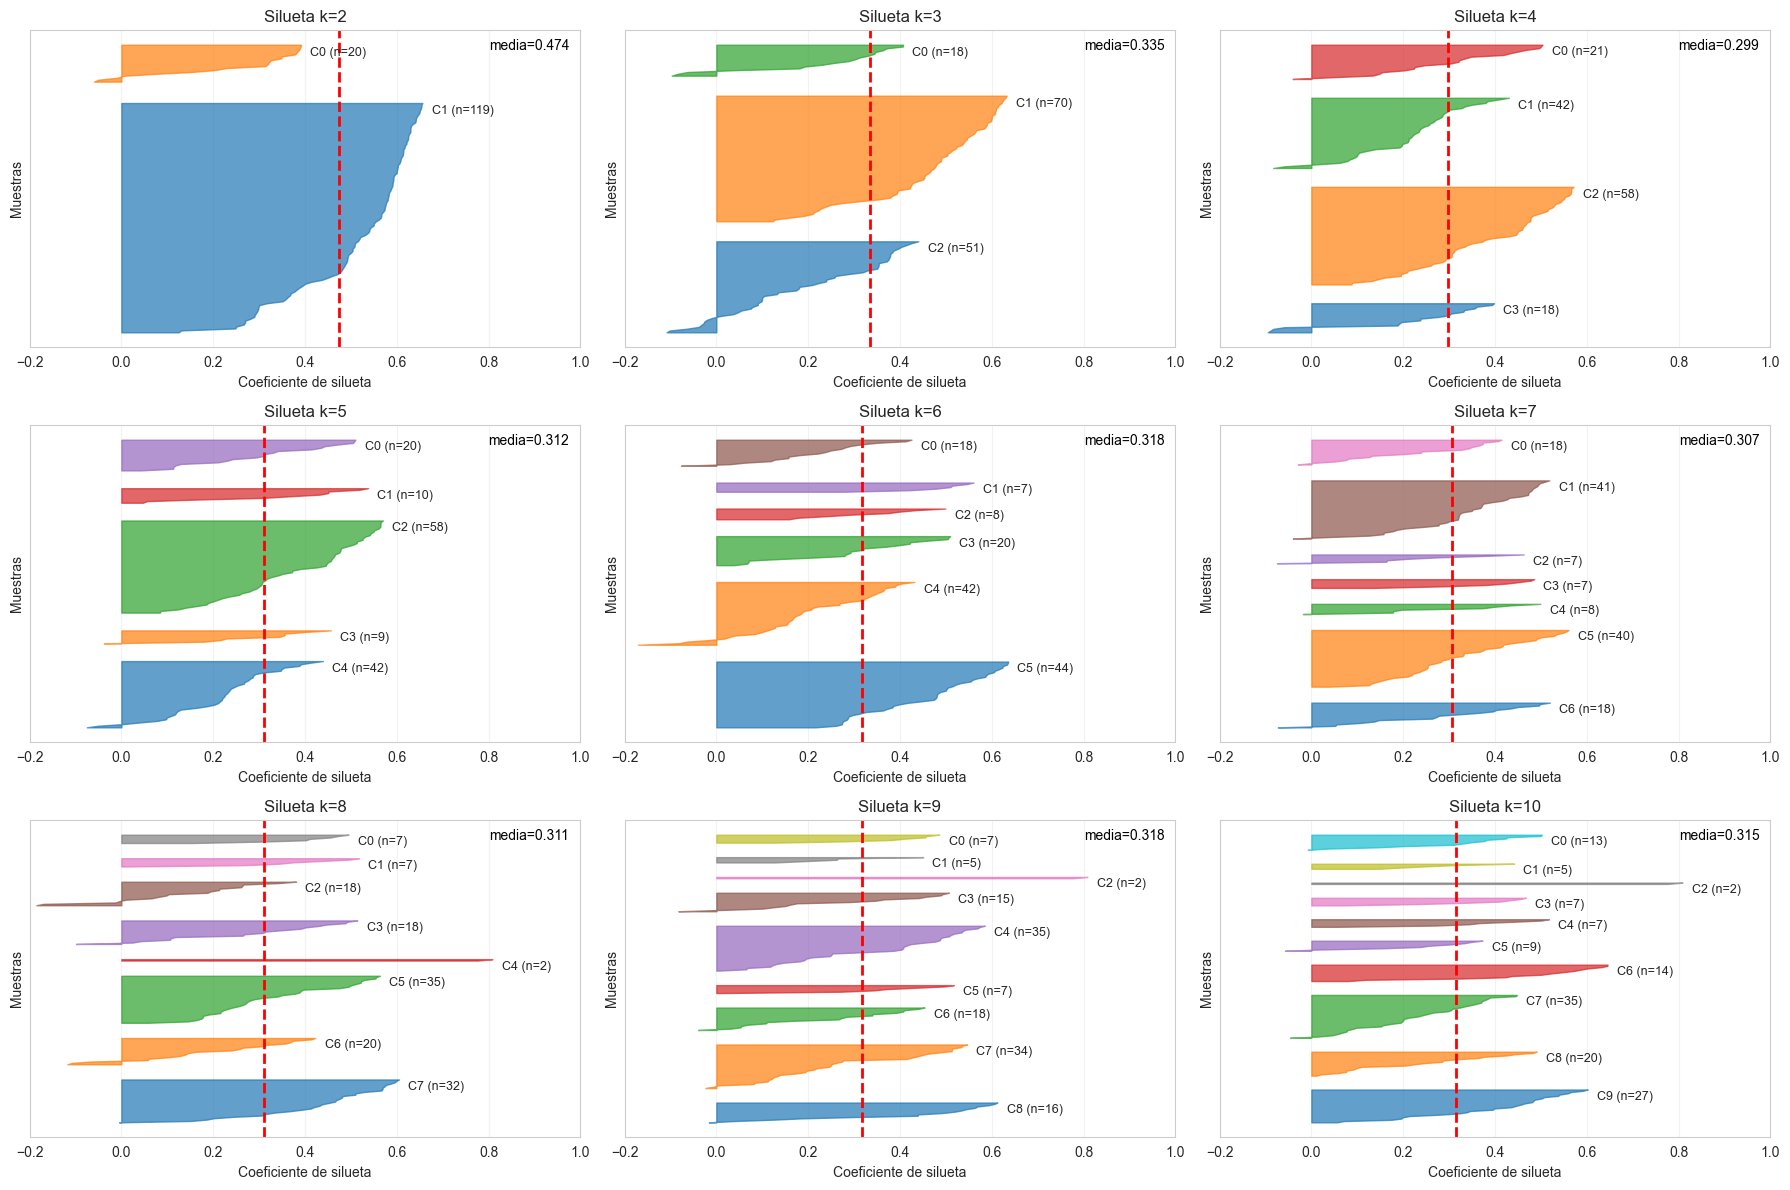

In [121]:
# Gráficos de silueta para varios k
plot_multi_silhouettes(Xp, ks=[2,3,4,5,6,7,8,9,10])


Viendo los gráficos y basandonos en los resultados anteriores, creemos que  k=4 es una buena decisión: más granular que 2–3, sin la sobre‐segmentación de 6–10. Las métricas no son máximas, pero están en la misma meseta razonable.
Además,  produce perfiles de negocio diferenciables con tamaños (mas) balanceados.

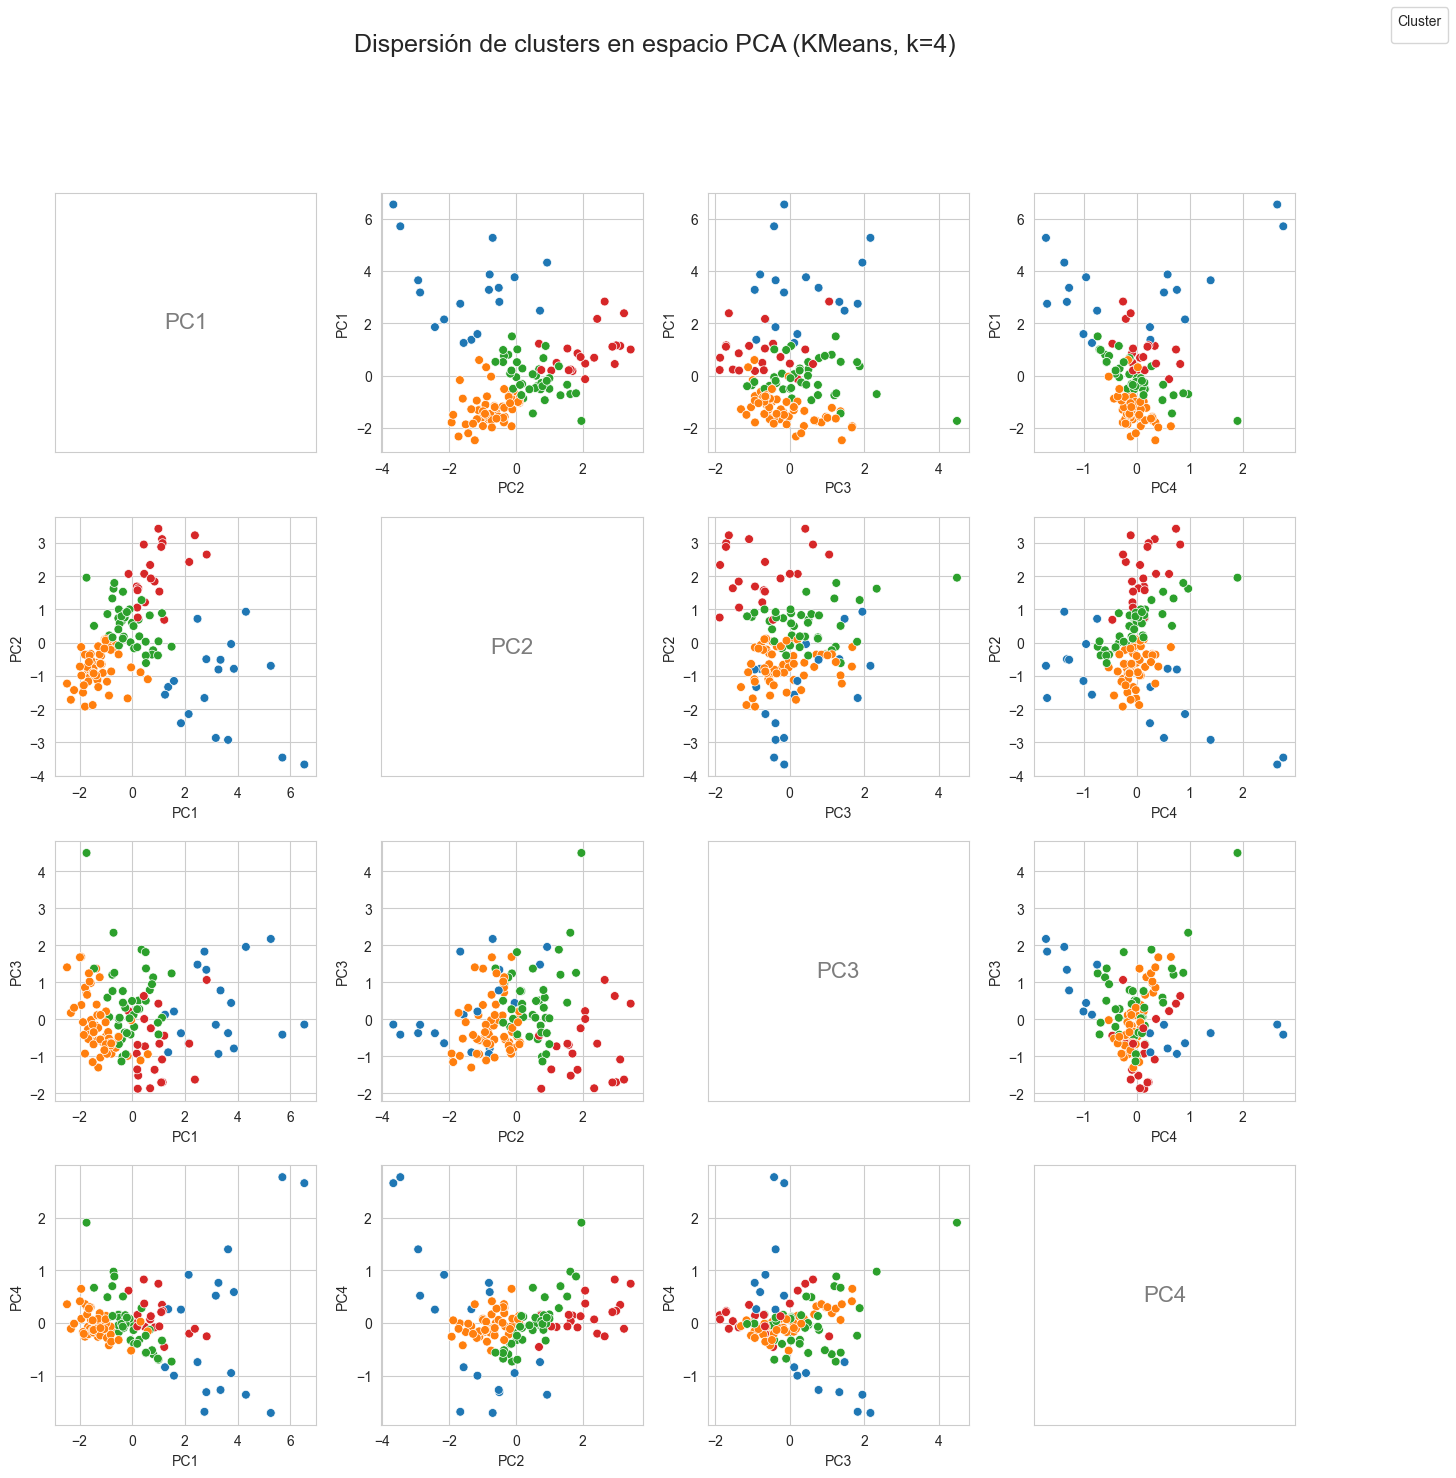

In [122]:
# KMeans final con K=4 por consideraciones relativas a la Silhuoette y a lógica de negocio
k_final = 4
km = KMeans(n_clusters=k_final, n_init=20, random_state=RANDOM_STATE)
labels_km = km.fit_predict(Xp)

feat["cluster_id"] = labels_km

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# DISPERSION PCA
n_pcs = 4
pcs = [f"PC{i+1}" for i in range(n_pcs)]

fig, axes = plt.subplots(n_pcs, n_pcs, figsize=(16, 16))
plt.subplots_adjust(hspace=0.25, wspace=0.25)

for i in range(n_pcs):
    for j in range(n_pcs):
        ax = axes[i, j]
        if i == j:
            # Diagonal: solo el nombre del componente
            ax.text(0.5, 0.5, pcs[i], fontsize=16, ha='center', va='center', alpha=0.6)
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            # Gráfico de dispersión: PCi vs PCj
            sns.scatterplot(
                x=Xp[:, j], y=Xp[:, i], hue=labels_km, palette="tab10", s=40, ax=ax, legend=False
            )
            ax.set_xlabel(pcs[j])
            ax.set_ylabel(pcs[i])

# Agrega leyenda solo una vez
handles, labels = axes[0, 1].get_legend_handles_labels()
fig.legend(handles, labels, title="Cluster", loc="upper right", fontsize=12)

fig.suptitle(f"Dispersión de clusters en espacio PCA (KMeans, k={k_final})", fontsize=18, y=0.98)
plt.show()

Los 4 clusters muestran nubes distinguibles en varias combinaciones de PCs (no perfectas, pero con separación visual razonable), lo que respalda la elección de k=4. (se fué haciendo a pruab y error)

Métricas generales de cada cluster (justificando esta clusterización)

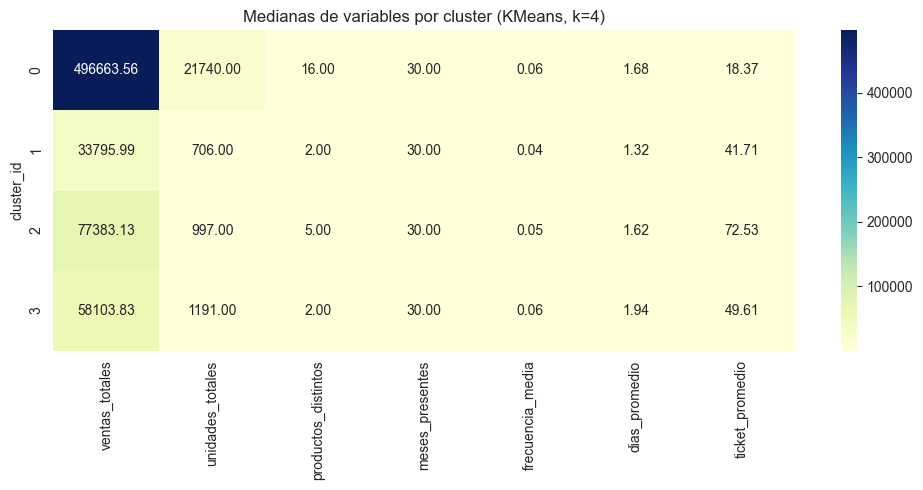

,ventas_totales,unidades_totales,productos_distintos,meses_presentes,frecuencia_media,dias_promedio,ticket_promedio
cluster_id,,,,,,,
0,496663.564305,21740.0,16.0,30.0,0.055421,1.683719,18.368529
1,33795.993029,706.0,2.0,30.0,0.043358,1.318182,41.706460
2,77383.131780,997.0,5.0,30.0,0.053401,1.622210,72.530349
3,58103.825116,1191.0,2.0,30.0,0.063929,1.940678,49.608200


In [123]:
# Perfilado de clusters (medianas por variable)
cols_num = [
    "ventas_totales","unidades_totales","productos_distintos",
    "meses_presentes","frecuencia_media","dias_promedio","ticket_promedio"
]

perfil = (feat
          .groupby("cluster_id")[cols_num]
          .median()
          .sort_index())

plt.figure(figsize=(10,5))
sns.heatmap(perfil, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Medianas de variables por cluster (KMeans, k={k_final})")
plt.tight_layout()
plt.show()

perfil


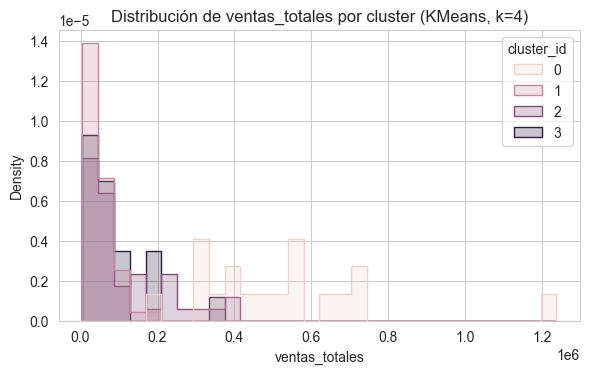

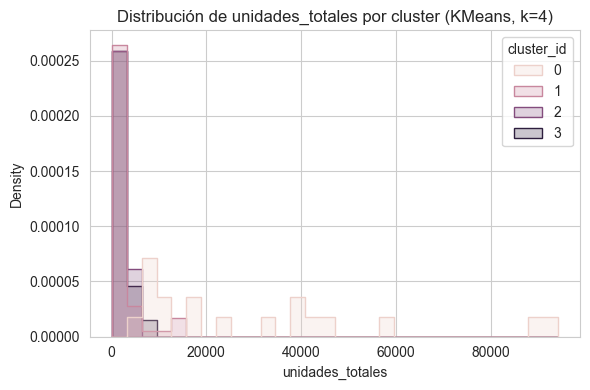

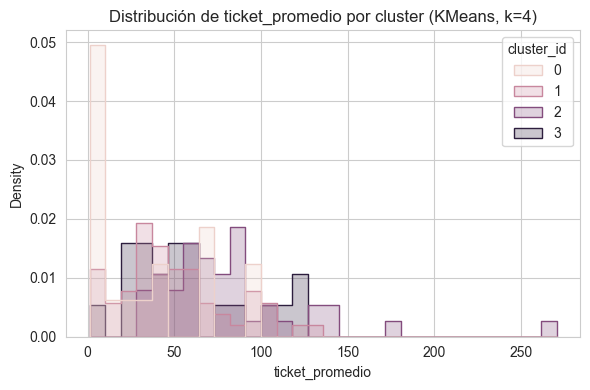

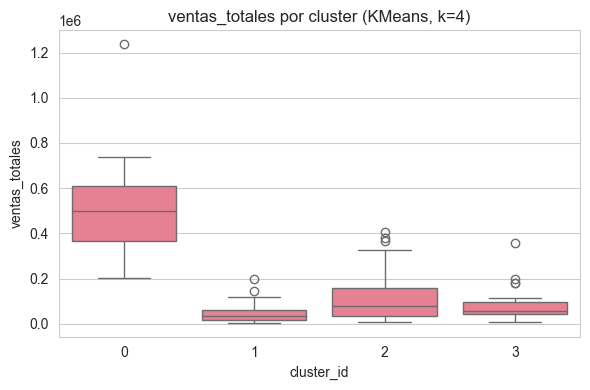

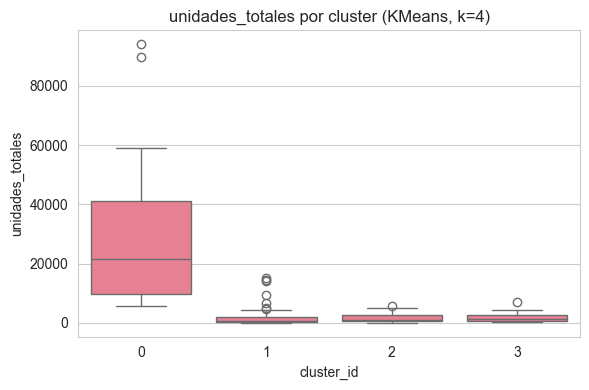

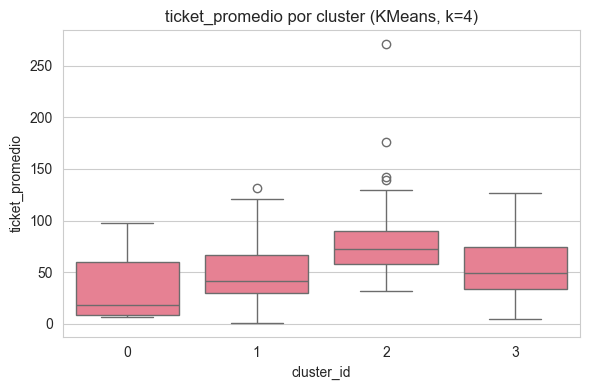

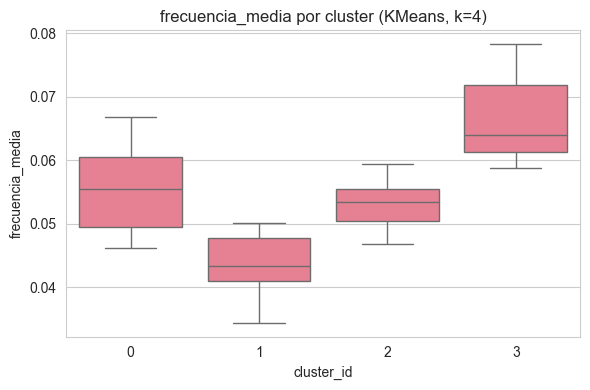

In [124]:
#  Distribuciones de variables clave por cluster

# Histogramas comparativos
vars_hist = ["ventas_totales", "unidades_totales", "ticket_promedio"]
for v in vars_hist:
    plt.figure(figsize=(6,4))
    sns.histplot(data=feat, x=v, hue="cluster_id", bins=30, element="step", stat="density", common_norm=False)
    plt.title(f"Distribución de {v} por cluster (KMeans, k={k_final})")
    plt.tight_layout()
    plt.show()

# Boxplots comparativos
vars_box = ["ventas_totales","unidades_totales","ticket_promedio","frecuencia_media"]
for v in vars_box:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=feat, x="cluster_id", y=v)
    plt.title(f"{v} por cluster (KMeans, k={k_final})")
    plt.tight_layout()
    plt.show()


In [125]:
# Top productos por cluster
# Merge df original (nivel transacción/mes) con los clusters finales
df_clusters = df.merge(feat[["cliente","cluster_id"]], on="cliente", how="left")

# Top productos por cluster según unidades totales
top_prods = (df_clusters.groupby(["cluster_id","produc"])["unidades_totales"]
             .sum()
             .reset_index()
             .sort_values(["cluster_id","unidades_totales"], ascending=[True,False]))

# Seleccionar top-5 de cada cluster
top5_by_cluster = top_prods.groupby("cluster_id").head(10)


In [ ]:
# Veremos que productos hay a ver si encontramos un patrón
desc_df = raw_df[['produc', 'descrip']].drop_duplicates(subset=['produc'])

# Hacemos merge para poder ver qué productos son
top5_by_cluster_desc = top5_by_cluster.merge(desc_df, on='produc', how='left')

# Top 3 productos por cluster (0-1-2-3)
top3_by_cluster_desc = (
    top5_by_cluster_desc[top5_by_cluster_desc['cluster_id'].isin([0, 1, 2, 3])]
    .groupby('cluster_id', group_keys=False)
    .head(3)
)

display(top3_by_cluster_desc)

,cluster_id,produc,unidades_totales,descrip
0,0,000-000-3113,79525.0,mogul frutales x 1 kg.
1,0,000-000-11834,55800.0,menta cristal x 810 grs.
2,0,000-000-11828,49410.0,rellenos miel x 675 grs.
10,1,000-000-13099,22400.0,mogul frutales x 220 grs.
11,1,000-000-13612,10443.0,serranitas arcor 3 x 105 grs.
12,1,000-000-3113,9540.0,mogul frutales x 1 kg.
20,2,000-000-6140,4381.0,alf. bon o bon triple x 60 grs
21,2,000-000-5312,4230.0,NaN
22,2,000-000-11283,4215.0,cofler block x 110 grs.
30,3,000-000-3081,7220.0,mogul jelly buttons x 1 kg


###########     REVISAR POR QUE HAY UN NAN!! ###########################

In [74]:
#Helper para normalizar valores pre radar plot
def normalize_profile(df: pd.DataFrame, how: str = "minmax") -> pd.DataFrame:

    if how == "minmax":
        denom = (df.max() - df.min()).replace(0, 1)  
        return (df - df.min()) / denom
    elif how == "zscore":
        std = df.std(ddof=0).replace(0, 1)
        return (df - df.mean()) / std
    else:
        raise ValueError("how debe ser 'minmax' o 'zscore'")

In [75]:
def plot_radar_small_multiples(
    perfil: pd.DataFrame,
    title: str = "Perfiles por cluster (Radar)",
    normalize: str | None = "minmax",
    ncols: int | None = 3,            # si K==6, forzamos 2x3
    cmap_name: str = "tab10",
    alpha_fill: float = 0.18,
    line_width: float = 2.2,
    show_values: bool = False,        # muestra valores en cada vértice
    value_fmt: str = ".2f",
):
    """
    perfil: DataFrame con index = cluster_id y columnas = variables numéricas
    """

    # quitar columnas con varianza ~0 (no aportan)
    keep_cols = [c for c in perfil.columns if np.nanstd(perfil[c].values) > 1e-12]
    df = perfil[keep_cols].copy()

    # normalización (opcional)
    df_norm = normalize_profile(df, how=normalize)

    labels = list(df_norm.columns)
    K, N = df_norm.shape[0], df_norm.shape[1]

    # ángulos (cerramos polígono)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    # layout: si K==6 -> 2x3; si no, arma grilla “cuadrada”
    if K == 6:
        rows, cols = 2, 3
    else:
        if ncols is None:
            cols = math.ceil(math.sqrt(K))
        else:
            cols = int(ncols)
        rows = math.ceil(K / cols)

    fig, axes = plt.subplots(
        rows, cols,
        subplot_kw=dict(polar=True),
        figsize=(4.6*cols, 4.8*rows)
    )
    axes = np.atleast_2d(axes)

    cmap = plt.get_cmap(cmap_name, max(K, 10))

    # límites radiales coherentes
    if normalize == "minmax":
        rmin, rmax = 0.0, 1.0
        rticks = [0.25, 0.5, 0.75, 1.0]
        rticklabels = ["0.25","0.5","0.75","1.0"]
    else:
        # si no está normalizado podrías fijar automáticamente límites comunes
        # por defecto dejamos que matplotlib ajuste; si querés forzar:
        rmin, rmax = None, None
        rticks, rticklabels = None, None

    for i, (cid, row) in enumerate(df_norm.iterrows()):
        r, c = divmod(i, cols)
        ax = axes[r, c]

        vals = row.values.tolist()
        vals += vals[:1]

        # estética polar
        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=9)
        for lab in ax.get_xticklabels():
            lab.set_va("center")
            lab.set_ha("center")

        if rmin is not None and rmax is not None:
            ax.set_ylim(rmin, rmax)
        if rticks is not None:
            ax.set_yticks(rticks)
            ax.set_yticklabels(rticklabels, fontsize=8, alpha=0.8)
        ax.grid(alpha=0.28, linewidth=0.8)
        ax.spines["polar"].set_alpha(0.2)

        color = cmap(i % cmap.N)
        ax.plot(angles, vals, linewidth=line_width, color=color)
        ax.fill(angles, vals, color=color, alpha=alpha_fill)

        # valores en vértices (opcional)
        if show_values:
            raw_vals = perfil.loc[cid, labels]  # valores originales o normalizados?
            # mostramos los normalizados para consistencia con el gráfico:
            vshow = row.values
            for a, v in zip(angles[:-1], vshow):
                ax.text(
                    a, min(v + 0.05, ax.get_rmax() if normalize=="minmax" else v + 0.05),
                    f"{v:.2f}",
                    fontsize=8, ha="center", va="bottom", alpha=0.8
                )

        ax.set_title(f"Cluster {cid}", y=1.08, fontsize=11, fontweight="600")

    # ejes sobrantes
    for j in range(K, rows*cols):
        r, c = divmod(j, cols)
        axes[r, c].axis("off")

    fig.suptitle(title, y=1.02, fontsize=14, fontweight="600")
    plt.tight_layout()
    return fig, axes

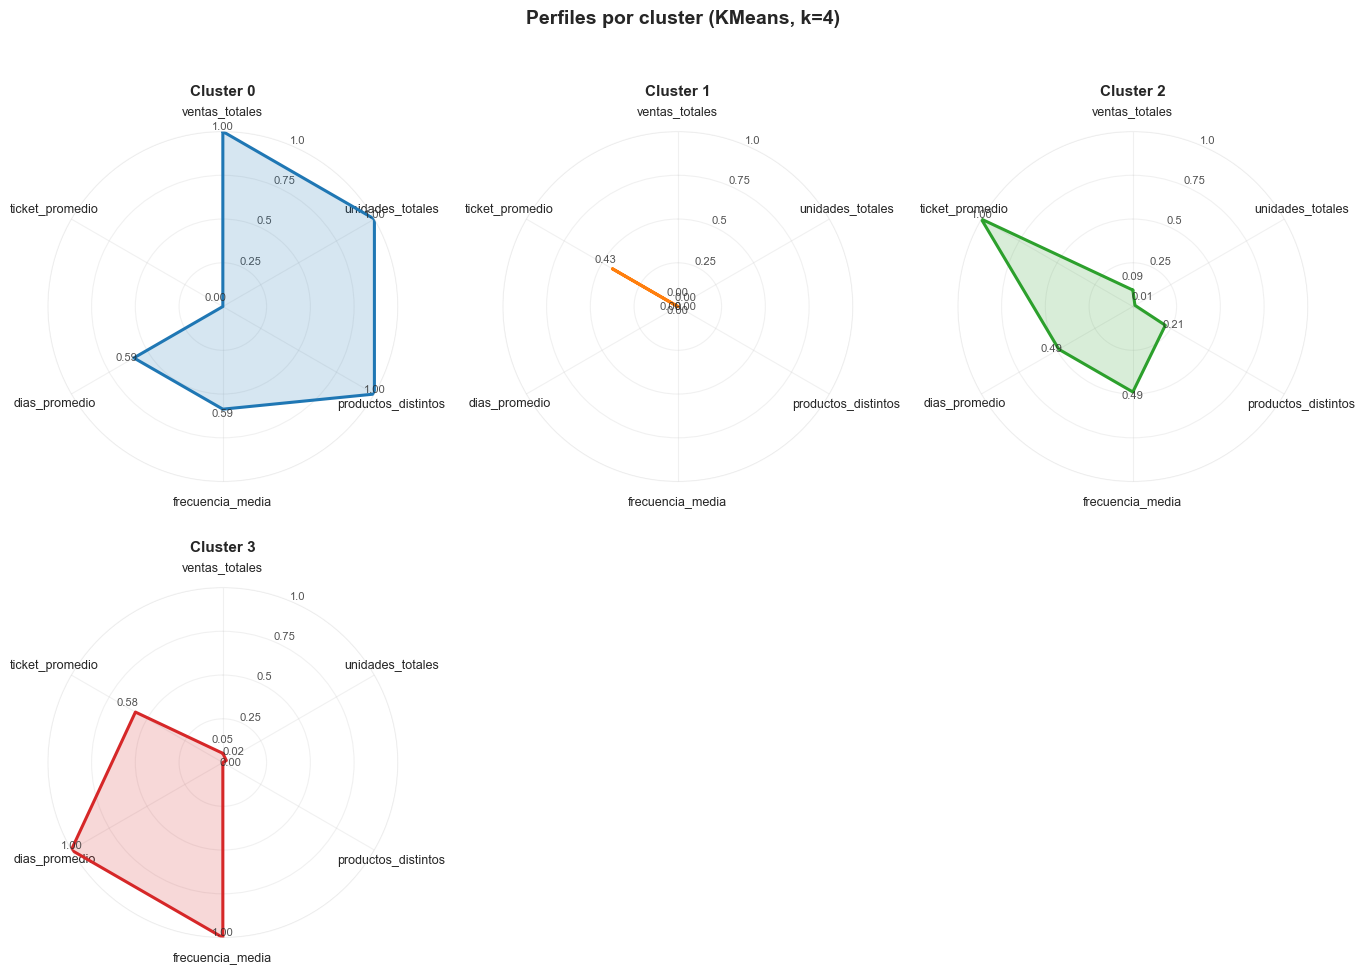

In [76]:
fig, axes = plot_radar_small_multiples(
    perfil,
    title=f"Perfiles por cluster (KMeans, k={k_final})",
    normalize="minmax",     # 
    ncols=3,                
    alpha_fill=0.18,
    line_width=2.2,
    show_values=True       
)
plt.show()

Conclusión de clusterización:

**Perfiles y distribución por variables (tablas, KDE y boxplots)**

- Concentración 80/20 clara:

    -Cluster 0 concentra la mayor venta y unidades; distribuciones (KDE/boxplots) desplazadas a la derecha con colas largas → PDVs de alto volumen.

- Ticket promedio:

    -Cluster 2 tiene el ticket más alto (perfil premium), con menos productos y volumen intermedio.

    -Cluster 0 opera con ticket más bajo (masivo/de volumen).

- Frecuencia y días activos:

    -Cluster 3 muestra la mayor frecuencia y más días de compra (cliente/PDV recurrente en pocos SKUs).

    -Cluster 1 es el de menor volumen y frecuencia más baja.

- Variedad (productos_distintos):

    -Cluster 0 destaca por alta variedad (≈16 SKUs), reforzando el perfil amplio/multicategoría.

    -Clusters 1 y 3 compran pocos SKUs (foco).

**Síntesis de los 4 clusters**

- C0 – Masivo/alto volumen: mucha venta y unidades, gran variedad, ticket bajo, frecuencia media.

- C1 – Bajo volumen/económico: poca venta y unidades, ticket medio-bajo, baja frecuencia.

- C2 – Premium focalizado: ticket más alto, variedad media-baja, volumen intermedio.

- C3 – Recurrente focalizado: alta frecuencia y días activos, pocos SKUs, volumen bajo-medio.

In [77]:
# Guardamos la asignación de clusters (El profe lo pide en la consigna, ya los usaremos mas adelante)

clusters_out = (
    feat[["cliente", "cluster_id"]]
    .sort_values(["cluster_id", "cliente"])
    .reset_index(drop=True)
)


## 2) Sistema de Recomendación

In [78]:
#Acuerdensé de hacer copias de los df para no redefinir los dataframes originales
df = raw_df.copy()
df = df.merge(clusters_out, on="cliente", how="left")
print("Shape", df.shape)
print("Clientes unicos", df["cliente"].nunique())
print("Productos unicos", df["produc"].nunique())
print("Clusters", df["cluster_id"].nunique())

Shape (21060, 17)
Clientes unicos 139
Productos unicos 166
Clusters 4


1- Construimos un recomendador item-based. A partir del histórico transaccional armamos una matriz entidad×producto (cliente/PDV por SKU) donde la señal es la frecuencia de compra. 

2- Con esa matriz calculamos similitudes coseno entre productos: si dos ítems son comprados por conjuntos de entidades parecidos, los consideramos similares. 

3- Para recomendar, tomamos los ítems del historial de la entidad y promediamos (ponderado) las similitudes hacia ítems no comprados, retornando un Top-N. 

*Agregamos filtros mínimos de cobertura para reducir ruido y, como variantes, probamos binaria y TF-IDF para controlar el sesgo de popularidad. También dejamos un baseline de popularidad y la opción de filtrar por cluster (intra-cluster) según el cluster_id del punto de segmentación

Eje filas (entidad): cliente
Eje columnas (ítem): produc
Señal elegida: freq
Matriz: (68, 71)  (cliente × produc)
Sparsidad aprox.: 0.897


produc,000-000-10057,000-000-1009,000-000-10129,000-000-10130,000-000-10173,000-000-10174,000-000-10204,000-000-10340,000-000-10342,000-000-10885,000-000-11283,000-000-11554,000-000-11586,000-000-11646,000-000-11803,000-000-11809,000-000-11827,000-000-11828,000-000-11834,000-000-11913,000-000-12450,000-000-12490,000-000-12625,000-000-12882,000-000-12963,000-000-13099,000-000-13151,000-000-13216,000-000-13268,000-000-13296,000-000-13324,000-000-13325,000-000-13326,000-000-13348,000-000-13349,000-000-13358,000-000-13451,000-000-13612,000-000-13783,000-000-1732,000-000-1782,000-000-1999,000-000-2001,000-000-2170,000-000-3092,000-000-3113,000-000-3176,000-000-3274,000-000-3312,000-000-3313,000-000-3465,000-000-3466,000-000-3777,000-000-3870,000-000-3871,000-000-4013,000-000-4053,000-000-4056,000-000-5312,000-000-6020,000-000-6072,000-000-6074,000-000-6140,000-000-6596,000-000-6973,000-000-7049,000-000-7167,000-000-7198,000-000-8721,000-000-9341,000-000-9419
cliente,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
296,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,30.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
526,30.0,0.0,30.0,30.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,30.0,30.0,30.0,30.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0
901,30.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0
964,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,30.0
1299,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,30.0,30.0,0.0,0.0,0.0,0.0,0.0


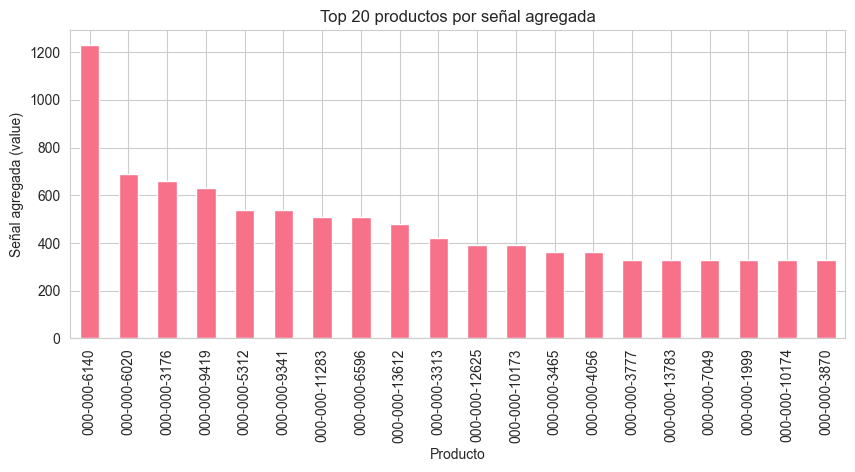

In [134]:
# matriz de interacciones para recomendador item-based
# matriz (PDV o cliente) × producto usando como señal la frecuencia de compra.


entity_col =  'cliente'   
item_col   = 'produc'                                      
signal     = 'freq'                                       

print(f"Eje filas (entidad): {entity_col}")
print(f"Eje columnas (ítem): {item_col}")
print(f"Señal elegida: {signal}")


# Filtros mínimos para reducir ruido/sparsidad (ir probando)
min_items_per_entity  = 3   # cada entidad debe haber comprado al menos 3 productos
min_entities_per_item = 3   # cada producto debe aparecer en al menos 3 entidades


# Construir DataFrame de interacciones cliente-producto con frecuencia de compra
interactions = (
    df.groupby([entity_col, item_col])
      .size()
      .reset_index(name='value')
)


# filtrarmos por lo que definimos arriba
valid_entities = (interactions.groupby(entity_col)[item_col]
                  .nunique().loc[lambda s: s>=min_items_per_entity]).index
valid_items    = (interactions.groupby(item_col)[entity_col]
                  .nunique().loc[lambda s: s>=min_entities_per_item]).index

interactions_f = interactions[interactions[entity_col].isin(valid_entities)
                              & interactions[item_col].isin(valid_items)]


# Matriz utilidad (entidad × ítem)
matrix = (interactions_f.pivot(index=entity_col, columns=item_col, values='value')
          .fillna(0.0).astype(float))




# check rápido
nonzeros = (matrix.values != 0).sum()
sparsity = 1 - (nonzeros / matrix.size)
print(f"Matriz: {matrix.shape}  ({entity_col} × {item_col})")
print(f"Sparsidad aprox.: {sparsity:.3f}")
display(matrix.head())

# vista rápida de popularidad de ítems (Top 20 por señal)
top_items = (
    interactions.groupby(item_col)['value'].sum()
    .sort_values(ascending=False).head(20)
)
ax = top_items.plot(kind='bar', figsize=(10,4), title='Top 20 productos por señal agregada')
ax.set_xlabel('Producto'); ax.set_ylabel('Señal agregada (value)')
plt.show()

# objetos para próximas celdas (similaridades)
X         = matrix.values            # matriz densa para cosenos
items     = matrix.columns.to_numpy()
entities  = matrix.index.to_numpy()



Resultados:

- Matriz 68×71 con sparsidad  aprox. 0.89: típico en recomendación. Está bien para item-based.

- Fuerte concentración en pocos productos (p. ej., 000-000-6140 lidera); existe “larga cola” de ítems poco frecuentes.

- Los conteos uniformes (muchos 30) sugieren compras en lotes; no afecta el coseno pero explica barras similares.

Matriz de similitud ítem–ítem: (71, 71)


,000-000-10057,000-000-1009,000-000-10129,000-000-10130,000-000-10173
000-000-10057,0.000000,0.0,0.365148,0.387298,0.235702
000-000-1009,0.000000,0.0,0.000000,0.000000,0.000000
000-000-10129,0.365148,0.0,0.000000,0.707107,0.387298
000-000-10130,0.387298,0.0,0.707107,0.000000,0.365148
000-000-10173,0.235702,0.0,0.387298,0.365148,0.000000


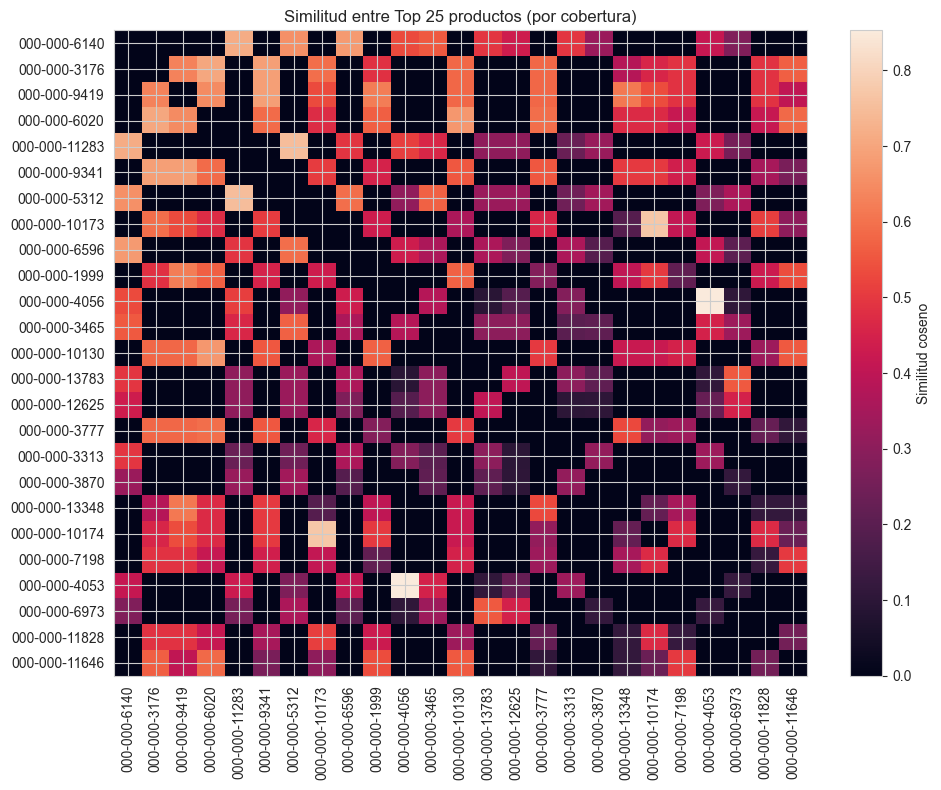

Ejemplo vecinos para: 000-000-6140


,similitud
000-000-11283,0.713477
000-000-6596,0.679366
000-000-5312,0.658281
000-000-3465,0.558156
000-000-4056,0.532181
000-000-13358,0.518875
000-000-6074,0.518875
000-000-13783,0.496139
000-000-3313,0.496139
000-000-11586,0.480384


In [80]:
# Similitud ítem–ítem (coseno) y chequeo visual

from sklearn.metrics.pairwise import cosine_similarity

# Similitud coseno entre columnas (productos)
# transponemos: items × entities
S = cosine_similarity(X.T)   # shape: (n_items, n_items)
np.fill_diagonal(S, 0.0)     # quitamos la auto-similitud
S = np.nan_to_num(S, nan=0.0, posinf=0.0, neginf=0.0)

S_df = pd.DataFrame(S, index=items, columns=items)

print("Matriz de similitud ítem–ítem:", S_df.shape)
display(S_df.iloc[:5, :5])

# Mapa de calor para los Top-N productos por popularidad
N = 25
top_items = (
    (matrix > 0).sum(axis=0)        # número de entidades que compraron cada producto
    .sort_values(ascending=False)
    .head(N).index
)
plt.figure(figsize=(10,8))
plt.imshow(S_df.loc[top_items, top_items].values, aspect='auto')
plt.colorbar(label='Similitud coseno')
plt.title(f"Similitud entre Top {N} productos (por cobertura)")
plt.xticks(ticks=np.arange(len(top_items)), labels=top_items, rotation=90)
plt.yticks(ticks=np.arange(len(top_items)), labels=top_items)
plt.tight_layout()
plt.show()

#función para consultar vecinos similares de un producto
def recomendar_similares(producto, k=10, min_sim=0.0):
    """
    Retorna los k productos más similares a 'producto' según coseno.
    - min_sim: umbral mínimo de similitud para filtrar ruido.
    """
    if producto not in S_df.index:
        raise ValueError(f"Producto {producto} no está en la matriz.")
    sims = S_df.loc[producto].copy()
    out = (sims[sims >= min_sim]
           .sort_values(ascending=False)
           .head(k))
    return out.to_frame(name='similitud')

# ejemplo
ejemplo = top_items[0] if len(top_items) > 0 else items[0]
print("Ejemplo vecinos para:", ejemplo)
display(recomendar_similares(ejemplo, k=10, min_sim=0.05))


Calculamos la similitud coseno ítem a ítem a partir de la matriz cliente×producto (transponiendo para comparar columnas),  armamos el DataFrame S_df (71×71) y visualizamos un heatmap para los Top-25 productos por cobertura.

Conclusiones clave

- La matriz de similitud está bien dimensionada (71×71) y sin auto-similitud (diagonal = 0).

- Hay pares muy cercanos: p. ej., 000-000-10129 ↔ 000-000-10130 ≈ 0.71, señal de co-compra fuerte.

- Existen ítems aislados (filas/columnas con muchos 0), como 000-000-1009, que tendrán menos poder para recomendar.

- El heatmap muestra bloques de productos relacionados; excelente para armar sustitutos/complementos en recomendaciones.

- recomendar_similares(producto, k) devuelve vecinos ordenados por coseno.

Ahora procederemos a pasar la matriz de similitud ítem–ítem a recomendaciones por entidad:

- Mapeamos (item_to_pos, entity_to_pos) para indexar filas/columnas.

- _masked_S(min_sim) aplica un umbral a la matriz de similitudes S para ignorar pares muy débiles.

- recomendar_para_entidad():

    - toma el vector de compras de la entidad u

    - calcula el score item-based scores = u @ S (suma ponderada de similitudes hacia cada ítem candidato)

    - normaliza el score dividiendo por la cantidad de vecinos que aportan a cada ítem (tu denom)

    - excluye ítems ya comprados y aplica filtro intra-cluster si se pide

    - devuelve el Top-k con coverage (cuántos vecinos respaldan cada recomendación) y el gráfico.

Ejemplo recomendaciones para cliente=296


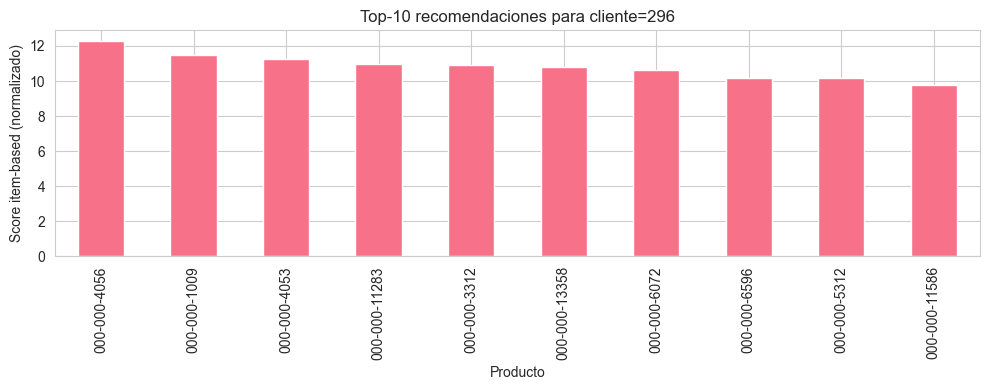

,produc,score,coverage
0,000-000-4056,12.273299,2.0
1,000-000-1009,11.503003,4.0
2,000-000-4053,11.271530,2.0
3,000-000-11283,10.987328,4.0
4,000-000-3312,10.932964,3.0
5,000-000-13358,10.785196,4.0
6,000-000-6072,10.626901,2.0
7,000-000-6596,10.161119,4.0
8,000-000-5312,10.146780,4.0
9,000-000-11586,9.798862,4.0


In [ ]:
# recomendaciones por entidad (cliente/PDV) 

entity_col = 'cliente'
item_col   = 'produc'


item_to_pos   = {it:i for i, it in enumerate(items)}
entity_to_pos = {e:i for i, e in enumerate(entities)}

#mapa de items por cluster para intra-cluster 
has_cluster = ('cluster_id' in df.columns) and (df['cluster_id'].notna().any())

if has_cluster:
    # Items que existen por cluster (con cobertura mínima para evitar ruido)
    min_entities_per_item_cluster = 2
    df_ic = (
        df[[entity_col, item_col, 'cluster_id']]
        .dropna(subset=['cluster_id'])
        .drop_duplicates([entity_col, item_col, 'cluster_id'])
        .groupby(['cluster_id', item_col])[entity_col]
        .nunique()
        .reset_index(name='n_entities')
    )
    df_ic = df_ic[df_ic['n_entities'] >= min_entities_per_item_cluster]
    items_por_cluster = (
        df_ic.groupby('cluster_id')[item_col]
             .apply(set)
             .to_dict()
    )
else:
    items_por_cluster = {}

# matriz S con umbral opcional para filtrar similitudes débiles
def _masked_S(min_sim=0.0):
    if min_sim <= 0:
        return S
    M = S.copy()
    M[M < min_sim] = 0.0
    return M

def recomendar_para_entidad(entidad, k=10, min_sim=0.0, intra_cluster=False, plot=True):

    if entidad not in entity_to_pos:
        raise ValueError(f"{entity_col} {entidad} no está en la matriz.")

    pos_e = entity_to_pos[entidad]
    u = X[pos_e, :]                 # vector de interacciones de la entidad (1 × n_items)

    # Máscara de items ya comprados (no recomendar repetidos)
    bought_mask = u > 0

    # Similitudes con umbral
    Sm = _masked_S(min_sim=min_sim)
    scores = u @ Sm                 # (n_items,)

    # Normalización opcional por la suma de similitudes que aportan a cada j (para evitar sesgos)
    denom = (bought_mask.astype(float) @ (Sm > 0).astype(float))  # cuántos vecinos contribuyen a cada j
    denom = np.where(denom == 0, 1.0, denom)
    scores = scores / denom

    # Nunca recomendar lo ya comprado
    scores = np.where(bought_mask, -np.inf, scores)

    # Filtro intra-cluster (si aplica)
    if intra_cluster and has_cluster:
        cluster_e = (
            df.loc[df[entity_col] == entidad, 'cluster_id']
              .dropna()
        )
        if len(cluster_e) > 0:
            c_id = cluster_e.mode().iloc[0]
            cand = items_por_cluster.get(c_id, set())
            mask_cluster = np.array([ (it in cand) for it in items ])
            scores = np.where(mask_cluster, scores, -np.inf)

    # Top-k
    top_idx = np.argsort(scores)[::-1][:k]
    top_items = items[top_idx]
    top_scores = scores[top_idx]

    # Cobertura (# de items comprados que aportan al score)
    coverage = (bought_mask.astype(float) @ (Sm[:, top_idx] > 0).astype(float))

    out = pd.DataFrame({
        item_col: top_items,
        'score':  top_scores,
        'coverage': coverage
    }).replace([np.inf, -np.inf], np.nan).dropna(subset=['score'])

    # Visual
    if plot and len(out) > 0:
        plt.figure(figsize=(10,4))
        out.set_index(item_col)['score'].plot(kind='bar')
        plt.title(f"Top-{k} recomendaciones para {entity_col}={entidad}")
        plt.xlabel("Producto"); plt.ylabel("Score item-based (normalizado)")
        plt.tight_layout(); plt.show()

    return out.sort_values('score', ascending=False)

# check
ejemplo_entidad = entities[0]
print(f"Ejemplo recomendaciones para {entity_col}={ejemplo_entidad}")
display(recomendar_para_entidad(ejemplo_entidad, k=10, min_sim=0.05, intra_cluster=False, plot=True))


Generamos para el cliente 296 su Top-10 de recomendaciones con un item-based coseno: usamos sus compras como “anclas”, combinamos similitudes con los ítems no comprados, normalizamos el score y excluimos lo ya comprado.

Conclusiones

- Confianza alta: scores ~9.8–12.3; los más fuertes: 000-000-4056, 000-000-1009, 000-000-4053.
- Soporte real: coverage entre 2 y 4 indica que varias compras previas respaldan cada recomendación (menos riesgo).
- Equilibrio popularidad-afinidad: aparecen ítems frecuentes pero también relacionados por co-compra.

Recomendando: 100%|██████████| 68/68 [00:01<00:00, 58.57it/s]

Recomendaciones generadas: (680, 5)


,entidad,producto,score,coverage,rank
0,296,000-000-4056,12.273299,2.0,1
1,296,000-000-1009,11.503003,4.0,2
2,296,000-000-4053,11.271530,2.0,3
3,296,000-000-11283,10.987328,4.0,4
4,296,000-000-3312,10.932964,3.0,5


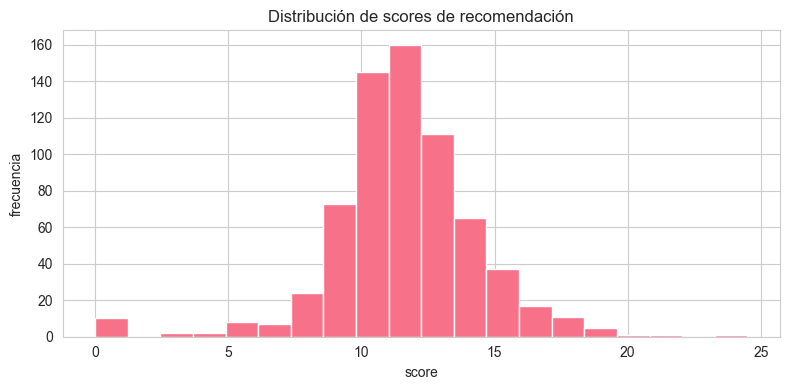

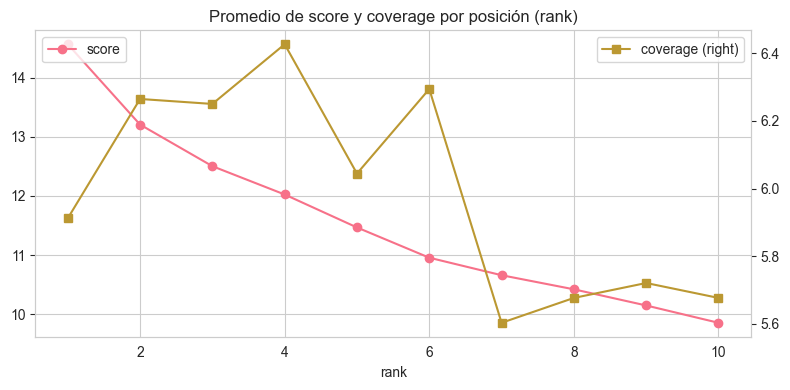

Explicabilidad para entidad=296, producto=000-000-4056


,item_comprado,sim,peso,rank
0,000-000-6140,0.532181,15.965435,1
1,000-000-3313,0.286039,8.581163,2


In [136]:
# Generar recomendaciones para TODAS las entidades y guardar


def explicar_contribucion(entidad, producto_objetivo, top_m=5, min_sim=0.0):
    """
    Explica qué ítems COMPRADOS por la entidad más contribuyen al score del producto recomendado.
    Devuelve un DataFrame con columnas: item_comprado, sim, peso (u_i * sim), y ranking.
    """
    if entidad not in entity_to_pos:
        raise ValueError(f"{entity_col} {entidad} no está en la matriz.")
    if producto_objetivo not in item_to_pos:
        raise ValueError(f"Producto {producto_objetivo} no está en la matriz.")

    e = entity_to_pos[entidad]
    j = item_to_pos[producto_objetivo]

    u = X[e, :]                          # compras de la entidad
    bought_idx = np.where(u > 0)[0]      # índices de items comprados

    sims = S[bought_idx, j]              # similitud de cada item comprado con el objetivo
    if min_sim > 0:
        mask = sims >= min_sim
        bought_idx = bought_idx[mask]
        sims = sims[mask]

    pesos = u[bought_idx] * sims
    order = np.argsort(pesos)[::-1]
    bought_idx = bought_idx[order][:top_m]
    sims = sims[order][:top_m]
    pesos = pesos[order][:top_m]

    return pd.DataFrame({
        "item_comprado": items[bought_idx],
        "sim": sims,
        "peso": pesos,
        "rank": np.arange(1, len(pesos)+1)
    })

def generar_recos_batch(k=10, min_sim=0.05, intra_cluster=False):
    """
    Genera Top-k recomendaciones para todas las entidades.
    Retorna un DataFrame largo con columnas: entidad, producto, score, coverage, rank.
    """
    todas = []
    for ent in tqdm(entities, desc="Recomendando"):
        df_rec = recomendar_para_entidad(ent, k=k, min_sim=min_sim,
                                         intra_cluster=intra_cluster, plot=False)
        if len(df_rec) == 0:
            continue
        df_rec = df_rec.reset_index(drop=False).rename(columns={item_col: "producto"})
        df_rec.insert(0, "entidad", ent)
        df_rec["rank"] = np.arange(1, len(df_rec)+1)
        todas.append(df_rec[["entidad", "producto", "score", "coverage", "rank"]])
    if len(todas) == 0:
        return pd.DataFrame(columns=["entidad", "producto", "score", "coverage", "rank"])
    return pd.concat(todas, ignore_index=True)

# Generar recomendaciones en lote
recos_all = generar_recos_batch(k=10, min_sim=0.05, intra_cluster=False)
print("Recomendaciones generadas:", recos_all.shape)
display(recos_all.head())

# Visualizaciones rápidas de diagnóstico
if len(recos_all) > 0:
    # Distribución de scores
    plt.figure(figsize=(8,4))
    recos_all["score"].plot(kind="hist", bins=20)
    plt.title("Distribución de scores de recomendación")
    plt.xlabel("score"); plt.ylabel("frecuencia")
    plt.tight_layout(); plt.show()

    # Coverage vs score (promedio por rank)
    tmp = recos_all.groupby("rank")[["score", "coverage"]].mean()
    ax = tmp["score"].plot(kind="line", figsize=(8,4), marker="o", label="score")
    ax2 = tmp["coverage"].plot(kind="line", marker="s", secondary_y=True, label="coverage")
    ax.set_title("Promedio de score y coverage por posición (rank)")
    ax.set_xlabel("rank")
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.tight_layout(); plt.show()

# Ejemplo de explicabilidad
if len(recos_all) > 0:
    ejemplo_ent = recos_all.iloc[0]["entidad"]
    ejemplo_prod = recos_all.iloc[0]["producto"]
    print(f"Explicabilidad para entidad={ejemplo_ent}, producto={ejemplo_prod}")
    expl = explicar_contribucion(ejemplo_ent, ejemplo_prod, top_m=5, min_sim=0.05)
    display(expl)


Conclusión:

Construimos matriz cliente×producto con señal de frecuencia.
Calculamos similitudes ítem–ítem (coseno).
Generamos Top-K por cliente, gráficos de control y explicabilidad (qué compras aportan al score). 
Exportamos recos_item_based_top10.csv. (No se si lo vamos a usar, ya veremos)

Hallazgos 
- Estructura sólida: matriz 68×71 con sparsing ~0.90 (normal en retail); el método item-based es apropiado.
- Relaciones claras entre productos: pares con coseno alto (p.ej. 10129↔10130 ≈ 0.71) ⇒ buen potencial de sustitución/upsell.
- Top-20 populares concentran demanda (p.ej. 000-000-6140) y sirven como “anclas” para recomendar a la larga cola.
- Recomendaciones con soporte real: en el ejemplo del cliente 296, coverage 2–4 vecinos por ítem ⇒ menor riesgo.
- Distribución de scores centrada ~10–12 y decrece con el rank ⇒ ranking consistente.

## 3) Ingeniería de series temporales

In [83]:
#Generamos de vuelta df
df = raw_df.copy()

#Le agregamos los clusters nuevamente

key_entidad = 'cliente' 
df = df.merge(clusters_out[[key_entidad, 'cluster_id']].drop_duplicates(),
                on=key_entidad, how='left')

print("Shape", df.shape)
# print("Cols", sorted(df.columns.tolist()))


Shape (21060, 17)


In [84]:
# creamos series mensuales por (PDV o cliente) × producto con lags, diffs, MAs y calendario.

entity_col = 'cliente'  # por consigna ideal: PDV×SKU
item_col   = 'produc'

# Señal objetivo para forecasting (prioridad: unidades > importe > frecuencia)
target_signal =  'unidades_totales' 
agg_fn = 'sum'


print(f"Granularidad: {entity_col} × {item_col} | Señal objetivo: {target_signal} ({agg_fn})")

# Columna de fecha 
date_candidates = ['mes']
date_col = date_candidates[0]

# Normalizamos a tipo datetime y a inicio-de-mes
df_dates = df.copy()
df_dates[date_col] = pd.to_datetime(df_dates[date_col])
df_dates['mes'] = df_dates[date_col].values.astype('datetime64[M]')  # periodo mensual (primer día del mes)

# -Agregación mensual por (entidad, item)

grp = (df_dates
        .groupby([entity_col, item_col, 'mes'])[target_signal]
        .sum().reset_index(name='y'))

# completarmos grilla mensual (imputando faltantes como 0)
# Rango mensual global
min_month = grp['mes'].min()
max_month = grp['mes'].max()
all_months = pd.date_range(min_month, max_month, freq='MS')

# Grilla completa por par (entidad, item)
pairs = grp[[entity_col, item_col]].drop_duplicates()
pairs['_key'] = 1
cal = pd.DataFrame({'mes': all_months})
cal['_key'] = 1
grid = (pairs.merge(cal, on='_key', how='left')
              .drop(columns=['_key']))

ts = (grid.merge(grp, on=[entity_col, item_col, 'mes'], how='left')
           .fillna({'y': 0.0}))

ts = ts.sort_values([entity_col, item_col, 'mes']).reset_index(drop=True) #nos aseguramos orden

# Features temporales (shift=1 para evitar fuga de info)
# Lags
for L in [1, 2, 3, 6, 12]:
    ts[f'lag_{L}'] = ts.groupby([entity_col, item_col])['y'].shift(L)

# Diffs
for D in [1, 12]:
    ts[f'diff_{D}'] = ts['y'] - ts.groupby([entity_col, item_col])['y'].shift(D)

# Moving averages (shift antes de promediar)
for W in [3, 6, 12]:
    ts[f'ma_{W}'] = (ts.groupby([entity_col, item_col])['y']
                       .shift(1)
                       .rolling(window=W, min_periods=1)
                       .mean())

# Calendario (mes, trimestre, año)
ts['month']   = ts['mes'].dt.month
ts['quarter'] = ts['mes'].dt.quarter
ts['year']    = ts['mes'].dt.year



# dropear NaN iniciales creados por lags 
cols_feat = [c for c in ts.columns if c not in [entity_col, item_col, 'mes', 'y']]
ts_clean = ts.dropna(subset=[c for c in cols_feat if c.startswith('lag_') or c.startswith('diff_')]).copy()

print("Panel final:", ts_clean.shape, "| columnas:", len(ts_clean.columns))
display(ts_clean.head())



Granularidad: cliente × produc | Señal objetivo: unidades_totales (sum)
Panel final: (12636, 17) | columnas: 17


,cliente,produc,mes,y,lag_1,lag_2,lag_3,lag_6,lag_12,diff_1,diff_12,ma_3,ma_6,ma_12,month,quarter,year
12,296,000-000-3313,2023-01-01,56.0,0.0,0.0,112.0,62.0,0.0,56.0,56.0,37.333333,43.000000,40.166667,1,1,2023
13,296,000-000-3313,2023-02-01,56.0,56.0,0.0,0.0,56.0,0.0,0.0,56.0,18.666667,42.000000,44.833333,2,1,2023
14,296,000-000-3313,2023-03-01,28.0,56.0,56.0,0.0,28.0,84.0,-28.0,-56.0,37.333333,42.000000,49.500000,3,1,2023
15,296,000-000-3313,2023-04-01,56.0,28.0,56.0,56.0,112.0,56.0,28.0,0.0,46.666667,42.000000,44.833333,4,2,2023
16,296,000-000-3313,2023-05-01,28.0,56.0,28.0,56.0,0.0,28.0,-28.0,0.0,46.666667,32.666667,44.833333,5,2,2023


- Se generaron lags (1,2,3,6,12), diffs (1,12) y promedios móviles (3,6,12 con shift) + calendario; exactamente lo pedido en la consigna.
- Tamaño del panel: 12,636 filas / 17 columnas → suficiente para modelar.


NaNs totales en ts_clean: 0


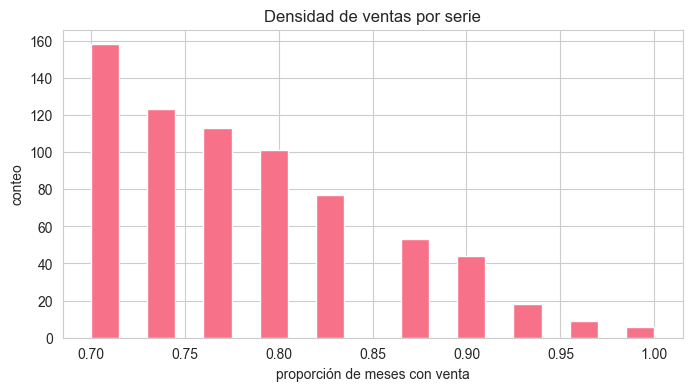

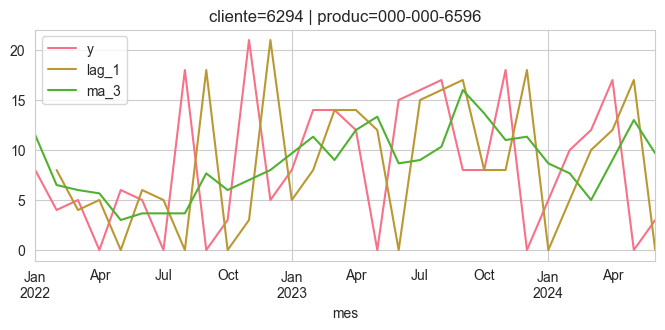

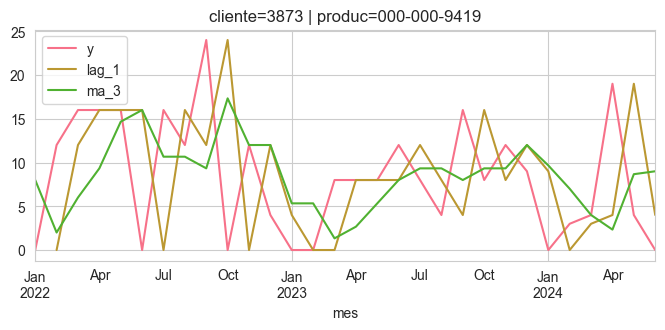

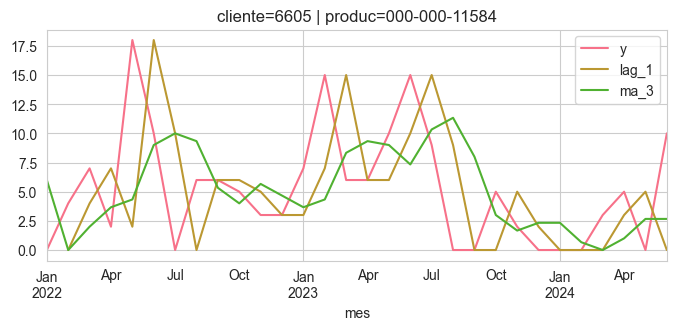

In [85]:
# check 1: densidad de ventas (meses con y>0) por par entidad×producto
densidad = (ts.groupby([entity_col, item_col])['y']
              .apply(lambda s: (s>0).mean())
              .reset_index(name='densidad'))
ax = densidad['densidad'].plot(kind='hist', bins=20, figsize=(8,4), title='Densidad de ventas por serie')
ax.set_xlabel('proporción de meses con venta'); ax.set_ylabel('conteo')

# check 2: ejemplo de 3 series al azar
muestra = (ts.groupby([entity_col, item_col]).size()
           .sample(3, random_state=7).index.tolist())
for e,i in muestra:
    tmp = ts[(ts[entity_col]==e) & (ts[item_col]==i)].sort_values('mes')
    tmp[['mes','y','lag_1','ma_3']].set_index('mes').plot(figsize=(8,3), title=f'{entity_col}={e} | {item_col}={i}')
    
# check 3: chequeo de NaNs en features (debería ser 0 tras el drop inicial)
na = ts_clean.isna().sum().sum()
print('NaNs totales en ts_clean:', na)


**Conclusiones**

- Panel mensual cliente×producto con demanda: construimos el panel a nivel cliente×producto con y = unidades_totales, completando meses faltantes con 0.

- Ingeniería temporal (sin fuga): generamos lags (1,2,3,6,12), diffs (1,12) y promedios móviles (3,6,12 con shift(1)), más calendario (mes, trimestre, año).

- Orden temporal explícito: antes de shift/rolling ordenamos por [cliente/pdv, producto, mes] para garantizar consistencia.

- Calidad del panel: ts_clean quedó sin NaNs (0 NaNs) tras dropear los iniciales creados por lags/diffs.

- Densidad de ventas: calculamos la proporción de meses con y>0 por serie reflejando la intermitencia de la demanda.

- Ejemplos de series: los gráficos de 3 series al azar (y, lag_1, ma_3) muestran variación real en y . Cuando y tiene picos, los MA suavizan y los diffs capturan cambios.




## 4) Forecasting

In [86]:

# Horizontes
H_FORECAST = 3       
H_HOLDOUT  = 6       
SEASONAL_M = 12 # Estacionalidad anual (12 meses), esto puede revisarse y ajustarse. 
                #Mayor que esto no porque tenemos solo 30 meses, -6 de ventana de evaluación = 24. Con menos no llegamos ni a 2 ciclos.


# Columnas clave
entity_col = "cliente"   # PDV
item_col   = "produc"    # SKU
date_col   = "mes"
y_col      = "y"


In [87]:
#Definimos métrocas 
def sMAPE(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    d = np.abs(y_true) + np.abs(y_pred)
    d = np.where(d==0, 1.0, d)
    return float(np.mean(2.0*np.abs(y_pred - y_true) / d))

def MASE(y_true, y_pred, y_insample, m=1):
    y_true, y_pred, y_insample = map(np.asarray, (y_true, y_pred, y_insample))
    if len(y_insample) <= m: m = 1
    denom = np.mean(np.abs(y_insample[m:] - y_insample[:-m]))
    denom = 1.0 if denom==0 else denom
    return float(np.mean(np.abs(y_true - y_pred)) / denom)

def WAPE(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.sum(np.abs(y_true)); denom = 1.0 if denom==0 else denom
    return float(np.sum(np.abs(y_true - y_pred)) / denom)

def summarize_metrics(df_pred, y_true="y_true", y_pred="y_pred"):
    if df_pred.empty: return {"sMAPE": np.nan, "MASE": np.nan, "WAPE": np.nan}
    sm = sMAPE(df_pred[y_true], df_pred[y_pred])
    wa = WAPE(df_pred[y_true], df_pred[y_pred])
    ma = np.nan
    if {"y_insample","group_id"}.issubset(df_pred.columns):
        mases=[]
        for _, g in df_pred.groupby("group_id"):
            mases.append(MASE(g[y_true].values, g[y_pred].values, g["y_insample"].iloc[0]))
        if mases: ma = float(np.mean(mases))
    return {"sMAPE": sm, "MASE": ma, "WAPE": wa}

In [88]:
ts_ml = ts_clean.copy().sort_values([entity_col, item_col, date_col]).reset_index(drop=True)

# Cíclicos del mes como exógenos para capturar estacionalidad anual.
# El cluster entiendo que no en principio porque es constante a lo largo del tiempo para cada pdv. 
# Indicadores trimestrales? probados, no aportaron sobre los cíclicos (posible redundancia).
# Podrian agregarse fechas especiales (black fridays, dias festivos, etc)
ts_ml["month"] = ts_ml["month"] if "month" in ts_ml.columns else ts_ml[date_col].dt.month
ang = 2*np.pi*(ts_ml["month"]-1)/12.0
ts_ml["month_sin"] = np.sin(ang).astype("float32")
ts_ml["month_cos"] = np.cos(ang).astype("float32")

# USE_DIFFS y USE_LOG1P activan las transformaciones que mejor rindieron en nuestras 
# pruebas: diferenciales (para estabilizar nivel/cambios) y log1p del objetivo 
# (para comprimir colas y evitar negativos). Tras comparar ambas variantes, las dejamos en True por desempeño
USE_DIFFS = True
USE_LOG1P = True

base_feats = ['month_sin','month_cos','lag_1','lag_2','lag_3','lag_6','lag_12','ma_3','ma_6','ma_12']
diff_feats = ['diff_1','diff_12'] if USE_DIFFS else []
CAND_FEATS = base_feats + diff_feats
EXOG_COLS  = [c for c in CAND_FEATS if c in ts_ml.columns]

In [89]:
#La consigna pide separar los últimos 6 meses y verificar contra ventanas temporales (backtesting/origen móvil).
# Acá hacemos dos cortes de H=3 dentro de los últimos H_HOLDOUT=6.

def last_n_unique_dates(df, n):
    dates = np.sort(df[date_col].unique()); return dates[-n:]

def make_two_windows_indices(g_dates, H_hold=H_HOLDOUT, H=H_FORECAST):
    idx = np.arange(len(g_dates))
    #CORTE A    
    # Para entrenar hasta T-6 (excluye los últimos 6)
    a_train_end = len(g_dates) - H_hold
    # Test A: T-5, T-4 y T-3 (tres meses inmediatamente posteriores al corte de train)
    a_test_idx  = idx[a_train_end : a_train_end + H]

    #CORTE B    
    # Para entrenar hasta T-3
    b_train_end = len(g_dates) - H
    # Test B: T-2, T-1 y T (los últimos tres meses)
    b_test_idx  = idx[b_train_end : b_train_end + H]

    # Devolvemos dos tuplas (train_idx, test_idx) para A y B
    return [(idx[:a_train_end], a_test_idx),
            (idx[:b_train_end], b_test_idx)]



In [90]:
#pip install xgboost

In [91]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

## Definimos funciones de ajuste y predicción: Sarimax y XGB


def fit_predict_sarimax_group(g, tr_idx, te_idx,
                              order=(0,1,1), seas=(0,1,1,SEASONAL_M),
                              min_len=12):
    # g: una serie PDV×SKU (una sola combinación), ya filtrada por groupby
    g = g.sort_values(date_col).reset_index(drop=True)
    # y: target de la serie; X: exógenos (features de calendario/temporalidad)
    y = g[y_col].values
    X = g[EXOG_COLS].values if EXOG_COLS else None

    # Particionamos segun la ventana
    y_tr, y_te = y[tr_idx], y[te_idx]
    X_tr = X[tr_idx] if X is not None else None
    X_te = X[te_idx] if X is not None else None

    if len(y_tr) < min_len:
        return np.repeat(y_tr[-1] if len(y_tr) else 0.0, len(y_te))

    try:
        m = SARIMAX(y_tr, order=order, seasonal_order=seas, exog=X_tr,
                    enforce_stationarity=False, enforce_invertibility=False)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=UserWarning)
            res = m.fit(disp=False)
            pred = res.predict(start=len(y_tr), end=len(y_tr)+len(y_te)-1, exog=X_te)
        pred = np.asarray(pred)
        if not np.isfinite(pred).all():
            pred = np.repeat(y_tr[-1], len(y_te))
        return np.clip(pred, 0, None)
    except Exception:
        # Si el ajuste falla (series muy cortas/intermitentes), devolvemos naïve
        return np.repeat(y_tr[-1] if len(y_tr) else 0.0, len(y_te))


from xgboost import XGBRegressor
# XGBs factory
def make_xgb(params=None):
    base = dict(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    if params: base.update(params)
    return XGBRegressor(**base)

def fit_predict_xgb_group(g, tr_idx, te_idx, model=None):
    # g: una serie PDV×SKU (una combinación única) con lags/MAs y exógenos ya construidos
    g = g.sort_values(date_col).reset_index(drop=True)    
    # Target y matriz de features (lags, MAs, sinus/cos, y opcionalmente diffs)
    y = g[y_col].values
    if not EXOG_COLS:
        return np.repeat(y[tr_idx][-1] if len(tr_idx) else 0.0, len(te_idx))
    X = g[EXOG_COLS].values
    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr       = y[tr_idx]
    if len(y_tr) < 5:
        return np.repeat(y_tr[-1] if len(y_tr) else 0.0, len(te_idx))
    y_tr_fit = np.log1p(y_tr) if USE_LOG1P else y_tr
    model = model if model is not None else make_xgb()
    model.fit(X_tr, y_tr_fit)
    yhat = model.predict(X_te)
    if USE_LOG1P: yhat = np.expm1(yhat)
    return np.clip(yhat, 0, None)

# minigrid para XGB
def small_param_search(param_list):
    best, best_metrics = None, None
    for p in param_list:
        bt = backtest_models(ts_ml, model_factory=lambda: make_xgb(p))
        mo = compute_micro_macro(bt)
        row = mo.loc[mo["model"].eq("XGB")]
        wape = float(row["micro_WAPE"].values[0]) if not row.empty else np.inf
        if best is None or wape < best_metrics:
            best, best_metrics = p, wape
    return best, best_metrics

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
# Backtest y métricas

#Backtesting con dos ventanas (A y B) por serie PDV×SKU
def backtest_models(ts_df, model_factory=None):
    rows=[]
    for (e,i), g in ts_df.groupby([entity_col, item_col], sort=False):
        g = g.sort_values(date_col).reset_index(drop=True)
        dates = g[date_col].values
        splits = make_two_windows_indices(dates, H_HOLDOUT, H_FORECAST)
        if not splits: continue
        y = g[y_col].values
        for w_id, (tr_idx, te_idx) in enumerate(splits, 1):
            # SARIMAX
            yhat_sar = fit_predict_sarimax_group(g, tr_idx, te_idx)
            for k, (yt, yp) in enumerate(zip(y[te_idx], yhat_sar)):
                rows.append({
                    entity_col:e, item_col:i, "window":w_id, "date": dates[te_idx[k]],
                    "model":"SARIMAX", "y_true":yt, "y_pred":yp, "y_insample":y[tr_idx]
                })
            # XGB
           
            mdl = model_factory() if model_factory is not None else make_xgb()
            yhat_ml = fit_predict_xgb_group(g, tr_idx, te_idx, model=mdl)
            for k, (yt, yp) in enumerate(zip(y[te_idx], yhat_ml)):
                rows.append({
                    entity_col:e, item_col:i, "window":w_id, "date": dates[te_idx[k]],
                    "model":"XGB", "y_true":yt, "y_pred":yp, "y_insample":y[tr_idx]
                })
    pred = pd.DataFrame(rows)
    if not pred.empty:
        pred["group_id"] = pred[entity_col].astype(str)+"|"+pred[item_col].astype(str)
    return pred

# Micro = métrica sobre todos los puntos (sensible a magnitud).
# Macro = promedio de métricas por serie (cada serie pesa igual).
# Reportamos ambas porque nos interesa ver desempeño global y también “promedio por serie”.
def compute_micro_macro(df_pred):
    out=[]
    for mdl, g in df_pred.groupby("model"):
        micro = summarize_metrics(g)
        macro_rows=[summarize_metrics(s) for _, s in g.groupby("group_id")]
        macro = pd.DataFrame(macro_rows).mean(numeric_only=True).to_dict() if macro_rows else {}
        out.append({"model":mdl,
                    "micro_sMAPE":micro.get("sMAPE"), "micro_MASE":micro.get("MASE"), "micro_WAPE":micro.get("WAPE"),
                    "macro_sMAPE":macro.get("sMAPE"), "macro_MASE":macro.get("MASE"), "macro_WAPE":macro.get("WAPE")})
    return pd.DataFrame(out)

#La experimentación con la granularidad elegida mostró demanda intermitente de algunos SKUS
# y series cortas (holdout 6 + S=12), lo que degrada SARIMAX y mete ruido en métricas globales.
#Por eso evaluamos también con Pareto (Top-80%) para evaluar con foco de negocio.
#Reportamos OVERALL (micro/macro) para transparencia y TOP-80 para una estimación enfocada en los SKUs más relevantes

#El Pareto actual es global: sumamos las unidades históricas de todos los pares cliente×SKU, 
#los ordenamos de mayor a menor y nos quedamos con los pares cuya suma acumulada llega hasta el 80%
def top_pareto_groups(ts_df, coverage=0.80):
    last6 = last_n_unique_dates(ts_df, H_HOLDOUT)
    hist  = ts_df[~ts_df[date_col].isin(last6)]
    vol   = (hist.groupby([entity_col, item_col])[y_col]
                  .sum().reset_index().rename(columns={y_col:"vol_hist"}))
    vol   = vol.sort_values("vol_hist", ascending=False).reset_index(drop=True)
    vol["cum"] = vol["vol_hist"].cumsum()/vol["vol_hist"].sum()
    top  = vol[vol["cum"]<=coverage].copy()
    top["group_id"] = top[entity_col].astype(str)+"|"+top[item_col].astype(str)
    return set(top["group_id"])

def metrics_pareto(df_pred, ts_df, coverage=0.80):
    if df_pred.empty: return pd.DataFrame()
    top_set = top_pareto_groups(ts_df, coverage)
    rows=[]
    for mdl, g in df_pred.groupby("model"):
        g_top = g[g["group_id"].isin(top_set)]
        mic = summarize_metrics(g_top)
        rows.append({"model":mdl, "segment":f"Top{int(coverage*100)}",
                     "sMAPE":mic["sMAPE"], "MASE":mic["MASE"], "WAPE":mic["WAPE"],
                     "n_points":len(g_top)})
    return pd.DataFrame(rows)

### Observación:
 - En la experimentación observamos:
   * Muchas series con ventas muy bajas (3–10 unidades en 6 meses).
   * Granularidad fina (PDV×SKU) ⇒ demanda intermitente y esparsidad.
   * Con holdout de 6 meses y estacionalidad 12, varias series quedan con
     poco historial útil; SARIMAX emite mucho warning (Too few observations to estimate starting parameters%s) y se vuelve casi un naïve.
 - Conclusión: además de métricas OVERALL (micro/macro), necesitamos un foco
   en las series que más relevantes para el negocio (Pareto o por el estilo).

In [ ]:
# Comparación de modelos en backtest
bt_pred = backtest_models(ts_ml)
metrics_overall = compute_micro_macro(bt_pred).round(4)
metrics_p80     = metrics_pareto(bt_pred, ts_ml, coverage=0.80).round(4)

print("-- OVERALL (H=3, 2 ventanas) --")
display(metrics_overall)
print("\n-- Top 80% por volumen --")
display(metrics_p80)

# minigrid
candidates = [
    {"n_estimators":500, "max_depth":5, "learning_rate":0.05},# GANADOR. Comento el resto para replicar más rápido. Pero podríamos probar más.
    #{"n_estimators":600, "max_depth":6, "learning_rate":0.04},
    #{"n_estimators":700, "max_depth":5, "learning_rate":0.04},
]
best_params, best_wape = small_param_search(candidates)
print("Mejor set:", best_params, " | micro_WAPE:", round(best_wape, 4))

bt_best = backtest_models(ts_ml, model_factory=lambda: make_xgb(best_params))
display(compute_micro_macro(bt_best).round(4))
display(metrics_pareto(bt_best, ts_ml, coverage=0.80).round(4))


-- OVERALL (H=3, 2 ventanas) --


,model,micro_sMAPE,micro_MASE,micro_WAPE,macro_sMAPE,macro_MASE,macro_WAPE
0,SARIMAX,0.9914,1.2253,1.1635,0.9914,1.2253,1.4803
1,XGB,0.9864,0.7691,0.6612,0.9864,0.7691,0.8654



-- Top 80% por volumen --


,model,segment,sMAPE,MASE,WAPE,n_points
0,SARIMAX,Top80,1.0255,1.2487,1.2011,882
1,XGB,Top80,1.0731,0.7570,0.6654,882


Mejor set: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05}  | micro_WAPE: 0.6612


,model,micro_sMAPE,micro_MASE,micro_WAPE,macro_sMAPE,macro_MASE,macro_WAPE
0,SARIMAX,0.9914,1.2253,1.1635,0.9914,1.2253,1.4803
1,XGB,0.9864,0.7691,0.6612,0.9864,0.7691,0.8654


,model,segment,sMAPE,MASE,WAPE,n_points
0,SARIMAX,Top80,1.0255,1.2487,1.2011,882
1,XGB,Top80,1.0731,0.7570,0.6654,882


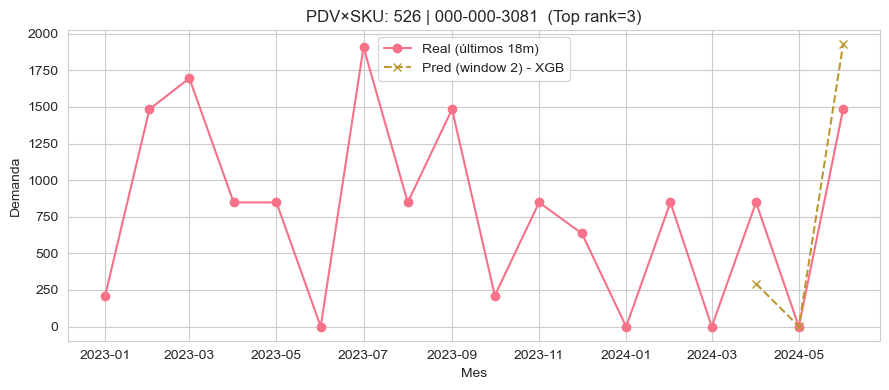

In [ ]:
# Gráfico para comparar prediccion del modelo xgb vs demanda real sobre un SKU puntual 
WINDOW_Q  = 2   # 1 = Corte A, 2 = Corte B (T-2..T)
PAIR_RANK = 3   # 1 = para elegir SKU con mayor volumen pre-holdout; 2 = segundo, etc.

# 1) Par PDV×SKU por volumen histórico (excluye holdout)
last6 = last_n_unique_dates(ts_ml, H_HOLDOUT)
hist  = ts_ml[~ts_ml[date_col].isin(last6)]
vol   = (hist.groupby([entity_col, item_col])[y_col].sum()
              .reset_index().rename(columns={y_col:"vol_hist"}))
vol   = vol.sort_values("vol_hist", ascending=False).reset_index(drop=True)
assert len(vol) >= PAIR_RANK, "PAIR_RANK excede la cantidad de pares disponibles."
top_e, top_i = vol.loc[PAIR_RANK-1, [entity_col, item_col]]

# 2) Serie real (últimos 18m) y predicciones XGB de la ventana elegida
g_all  = ts_ml[(ts_ml[entity_col]==top_e) & (ts_ml[item_col]==top_i)].sort_values(date_col)
g_last = g_all.tail(18).copy()
pred_xgb = (bt_pred[(bt_pred[entity_col]==top_e) & (bt_pred[item_col]==top_i)
                    & (bt_pred["model"]=="XGB") & (bt_pred["window"]==WINDOW_Q)]
            .sort_values("date"))

# 3) Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(9,4))
plt.plot(g_last[date_col], g_last[y_col], marker="o", label="Real (últimos 18m)")
if not pred_xgb.empty:
    plt.plot(pred_xgb["date"], pred_xgb["y_pred"], marker="x", linestyle="--",
             label=f"Pred (window {WINDOW_Q}) - XGB")
plt.title(f"PDV×SKU: {top_e} | {top_i}  (Top rank={PAIR_RANK})")
plt.xlabel("Mes"); plt.ylabel("Demanda")
plt.legend(); plt.tight_layout(); plt.show()


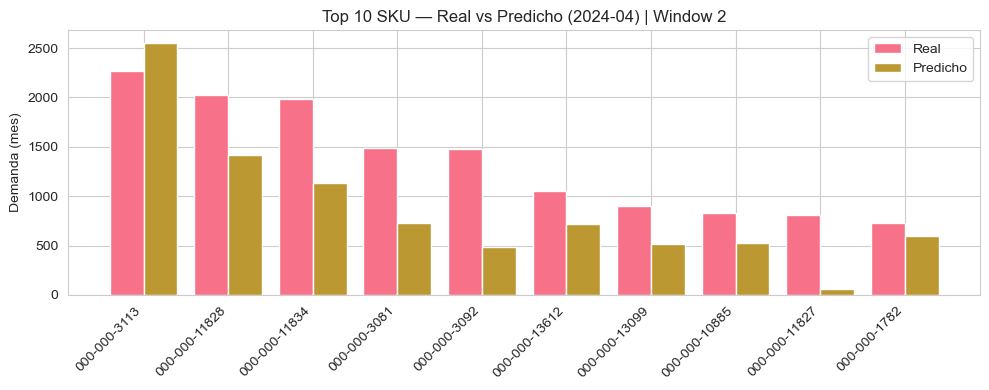

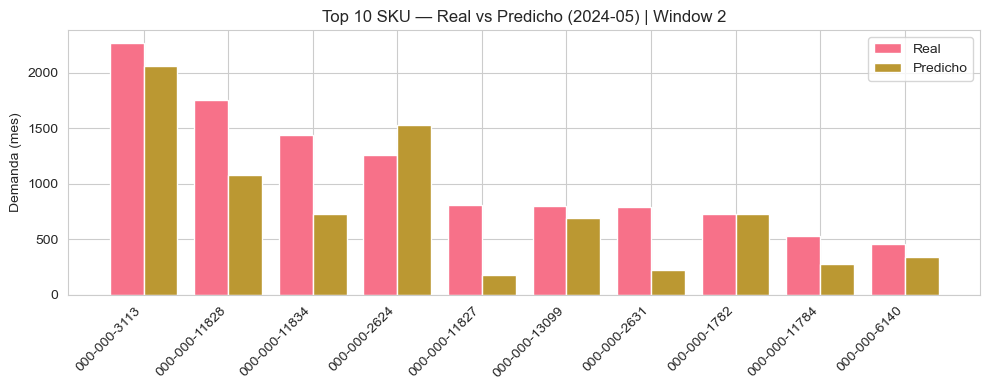

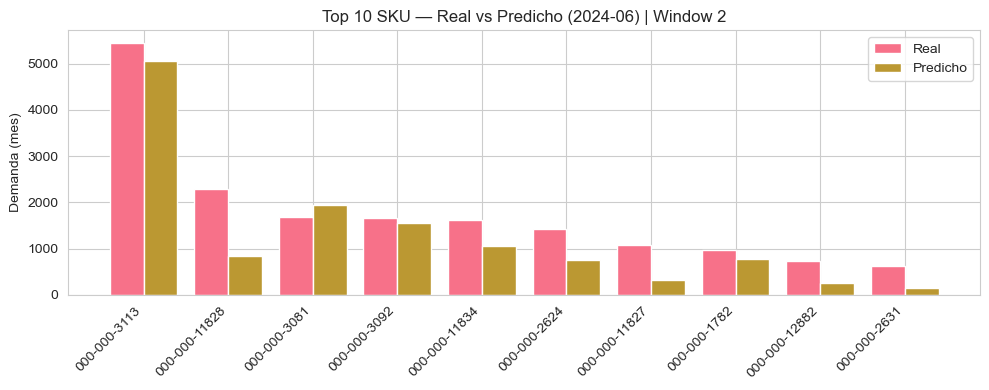

In [ ]:
# ===== Barras por mes del window (Top-K SKU) =====
MODEL_NAME = "XGB"   # modelo a graficar
WINDOW_Q   = 2       # 1 = Corte A (T-5..T-3), 2 = Corte B (T-2..T)
TOP_K      = 10      # cantidad de SKUs a mostrar por mes (ordenados por volumen real)

pred_w = (bt_pred[(bt_pred["model"]==MODEL_NAME) & (bt_pred["window"]==WINDOW_Q)]
          .copy().sort_values("date"))
months_w = np.sort(pred_w["date"].unique())
if len(months_w) == 0:
    raise ValueError("No hay predicciones para el window seleccionado.")

for m in months_w:
    # Agregado por SKU (suma PDV) para ese mes
    act_m = (ts_ml[ts_ml[date_col]==m]
             .groupby(item_col)[y_col].sum().rename("real"))
    pred_m = (pred_w[pred_w["date"]==m]
              .groupby(item_col)["y_pred"].sum().rename("pred"))

    cmp_m = (pd.concat([act_m, pred_m], axis=1)
               .fillna(0.0)
               .reset_index())

    # Top-K por volumen real del mes
    topk_m = (cmp_m.sort_values("real", ascending=False)
                    .head(TOP_K).reset_index(drop=True))

    # Plot barras lado a lado
    x = np.arange(len(topk_m)); w = 0.4
    plt.figure(figsize=(10,4))
    plt.bar(x - w/2, topk_m["real"].values, width=w, label="Real")
    plt.bar(x + w/2, topk_m["pred"].values, width=w, label="Predicho")
    plt.xticks(x, topk_m[item_col].astype(str), rotation=45, ha="right")
    plt.ylabel("Demanda (mes)")
    plt.title(f"Top {TOP_K} SKU — Real vs Predicho ({pd.to_datetime(m).strftime('%Y-%m')}) | Window {WINDOW_Q}")
    plt.legend(); plt.tight_layout(); plt.show()


### Conclusiones y Observaciones

- **Sobre SARIMAX**. Con granularidad PDV×SKU mensual aparecen muchas series con demanda intermitente y volúmenes muy bajos (p.ej., 3–10 unidades en 6 meses). Con holdout=6 y estacionalidad=12, varias quedan con historial corto para estimar componentes estacionales, generando warnings y comportamientos cercanos a un naïve. Además, la esparsidad (muchos ceros) debilita la suposición lineal/gaussiana del modelo.

- **Rendimiento alcanzado**. En backtesting (H=3, dos ventanas), XGB con log1p + diffs y lags/MAs superó consistentemente a SARIMAX:

    - Overall: XGB micro_WAPE ≈ 0.65 (vs. 1.16 en SARIMAX) y micro_MASE ≈ 0.77 (vs. 1.23); macro sigue la misma tendencia.

    - Top-80% (foco de negocio): XGB WAPE ≈ 0.65 con ~882 puntos evaluados; es decir, el error absoluto ponderado por volumen está alrededor del 65% del volumen real en los pares que concentran el 80% de las unidades.
    En términos prácticos: el modelo campeón reduce notoriamente el error donde “se juega” la mayor parte del negocio, y mantiene desempeño estable a nivel panel.

- **Qué podríamos hacer después.**

Ajustar la granularidad para algunas vistas (agregar SKU o PDV cuando la serie sea demasiado corta), y/o probar otrs modelos  (LightGBM/CatBoost).

Features exógenas reales: precios, promos, stockouts (cortes de stock), feriados/eventos; y cluster_id como exógeno/categórico en ML (XGB).

Segmentación de errores: por familia de producto, región, rango de volumen (no solo Top-80), para priorizar acciones.

Métricas x cluster

# 6) Rollings Multi Step

**Qué es rolling multi-step (H pasos):**
con datos hasta t predecimos t+1, anexamos esa predicción, recalculamos lags/medias móviles y recién ahí predecimos t+2… así hasta H. Simula cómo operaría el modelo mes a mes sin mirar el futuro.

In [ ]:
# Rolling recursivo validado en holdout (T-6 para predecir meses 25 a 30)
# Exógenas: solo calendario (month_sin/cos)
H_STEPS = 6  # consigna

#  Helpers de features para una serie (PDVxSKU)
def _add_calendar(df):
    if ("month_sin" in EXOG_COLS) or ("month_cos" in EXOG_COLS):
        m = df[date_col].dt.month
        ang = 2*np.pi*(m-1)/12.0
        if "month_sin" in EXOG_COLS: df["month_sin"] = np.sin(ang).astype("float32")
        if "month_cos" in EXOG_COLS: df["month_cos"] = np.cos(ang).astype("float32")
    return df

def _recompute_lags_ma(df):
    df = df.sort_values(date_col).copy()
    for L in [1,2,3,6,12]:
        c = f"lag_{L}"
        if c in EXOG_COLS:
            df[c] = df[y_col].shift(L)
    for W in [3,6,12]:
        c = f"ma_{W}"
        if c in EXOG_COLS:
            df[c] = df[y_col].shift(1).rolling(W, min_periods=1).mean()
    return df

# Entrena XGB con el histórico disponible y predice el valor del mes 'next_month'.
def _fit_predict_next(hist_df, next_month, random_state=42):
    tmp = hist_df.copy()
    blank = {entity_col: tmp[entity_col].iloc[0],
             item_col:   tmp[item_col].iloc[0],
             date_col:   next_month,
             y_col:      np.nan}
    for c in EXOG_COLS: blank[c] = np.nan
    tmp = pd.concat([tmp, pd.DataFrame([blank])], ignore_index=True)

    tmp = _add_calendar(tmp)
    tmp = _recompute_lags_ma(tmp)
    tmp = tmp.sort_values(date_col).reset_index(drop=True)

    X = tmp[EXOG_COLS]; y = tmp[y_col]
    X_next = X.iloc[[-1]]
    mask   = y.notna()
    X_tr, y_tr = X[mask], y[mask]

    # Usa mejor params si lo creamos anteriormente, sino default
    DEFAULT_XGB = dict(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        random_state=random_state, n_jobs=-1
    )
    cfg = DEFAULT_XGB.copy()
    if 'best_params' in globals() and isinstance(best_params, dict):
        cfg.update(best_params)
    model = XGBRegressor(**cfg)

    y_fit = np.log1p(y_tr) if USE_LOG1P else y_tr
    model.fit(X_tr.values, y_fit.values)
    y_hat = model.predict(X_next.values)[0]
    if USE_LOG1P: y_hat = np.expm1(y_hat)
    return float(max(0.0, y_hat))  # no negativos

# entrena hasta T-6 y simula t+1..t+6 recursivo 
def rolling_holdout_group(g, H=H_STEPS):
    g = g.sort_values(date_col).reset_index(drop=True)
    last6 = last_n_unique_dates(g, H)            # meses reales 25..30 de esa serie
    train = g[~g[date_col].isin(last6)]          # histórico hasta T-6

    # arrancamos histórico con los datos hasta T-6
    hist = train[[entity_col, item_col, date_col, y_col]].copy()
    out  = []

    current_end = hist[date_col].max()
    for next_month in last6:
        y_hat = _fit_predict_next(hist, next_month, random_state=RANDOM_STATE)
        out.append({
            entity_col: g[entity_col].iloc[0],
            item_col:   g[item_col].iloc[0],
            date_col:   next_month,
            "y_pred":   y_hat,
            "model":    "XGB_roll"
        })
        # anexamos la predicción como “observación” para el siguiente paso
        hist = pd.concat([hist, pd.DataFrame([{
            entity_col:g[entity_col].iloc[0],
            item_col:g[item_col].iloc[0],
            date_col:next_month,
            y_col:y_hat
        }])], ignore_index=True)
        current_end = next_month

    return pd.DataFrame(out)

#  Ejecutar rolling validado 
roll_val = (ts_ml.groupby([entity_col, item_col], sort=False)
              .apply(rolling_holdout_group, H=H_STEPS)
              .reset_index(drop=True))

#  Unimos con observaciones reales del holdout (meses T-5..T) para métricas 
last6_global = last_n_unique_dates(ts_ml, H_STEPS)
truth = (ts_ml[ts_ml[date_col].isin(last6_global)]
         [[entity_col, item_col, date_col, y_col]]
         .rename(columns={y_col:"y_true"}))

roll_eval = (roll_val.merge(truth, on=[entity_col, item_col, date_col], how="inner")
                    .assign(group_id=lambda d: d[entity_col].astype(str)+"|"+d[item_col].astype(str)))

#  Métricas OVERALL y Top-80 para rolling 
metrics_overall_roll = compute_micro_macro(roll_eval).round(4)
metrics_p80_roll     = metrics_pareto(roll_eval.rename(columns={"y_pred":"y_pred",
                                                                "y_true":"y_true"}),
                                      ts_ml, coverage=0.80).round(4)

print("=== OVERALL (Rolling H=6 en holdout) ===")
display(metrics_overall_roll)
print("\n=== Top 80% (Rolling H=6 en holdout) ===")
display(metrics_p80_roll)

#  Comparación vs XGB “no-rolling” del punto 4 (si bt_pred existe) 
if 'bt_pred' in globals() and not bt_pred.empty:
    # filtramos sólo meses del holdout global (25..30) para garantizar igualdad de condiciones (aunque en principio hicimos prediccion en misma ventana)
    bt_hold = bt_pred[(bt_pred["model"]=="XGB") & (bt_pred["date"].isin(last6_global))].copy()
    bt_hold = bt_hold.rename(columns={"date":date_col}).assign(
        group_id=lambda d: d[entity_col].astype(str)+"|"+d[item_col].astype(str)
    )
    print("\n Comparación rápida (micro-WAPE) ")
    wape_roll = WAPE(roll_eval["y_true"], roll_eval["y_pred"])
    wape_bt   = WAPE(bt_hold["y_true"], bt_hold["y_pred"]) if not bt_hold.empty else np.nan
    cmp_tbl = pd.DataFrame({"modelo":["XGB_roll (H=6)","XGB no-rolling (H=3 ventanas)"],
                            "micro_WAPE":[round(wape_roll,4), round(wape_bt,4)]})
    display(cmp_tbl)


=== OVERALL (Rolling H=6 en holdout) ===


/var/folders/t5/wcgk44md485d9qjr4b8z5wfh0000gp/T/ipykernel_68032/2310223562.py:95: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(rolling_holdout_group, H=H_STEPS)


,model,micro_sMAPE,micro_MASE,micro_WAPE,macro_sMAPE,macro_MASE,macro_WAPE
0,XGB_roll,1.0241,NaN,0.9679,1.0241,NaN,1.329



=== Top 80% (Rolling H=6 en holdout) ===


,model,segment,sMAPE,MASE,WAPE,n_points
0,XGB_roll,Top80,1.1173,NaN,0.9919,882



 Comparación rápida (micro-WAPE) 


,modelo,micro_WAPE
0,XGB_roll (H=6),0.9679
1,XGB no-rolling (H=3 ventanas),0.6612


### Conclusiones y Observaciones
- **¿Qué hicimos**
    - Entrenamos hasta T−6 (mes 24) y aplicamos rolling recursivo H=6 para predecir meses 25..30, recalculando lags/MA en cada paso (sin mirar futuro).

    - Calculamos sMAPE/MASE/WAPE en OVERALL y Top-80% (pares PDV×SKU que explican ~80% del volumen histórico en unidades).

    - Comparamos contra XGB no-rolling del punto 4.

- **Resultados clave**: El rolling rinde sensiblemente peor (micro-WAPE ≈ 0.97) que el XGB no-rolling (≈ 0.65) en los mismos 6 meses. Posible causa: el rolling propaga error (cada predicción alimenta a la siguiente) y, al no usar observaciones reales para los lags del holdout, el error es más complejo de enmendar que el backtesting “no-rolling” (que sí usa lags basados en valores reales previos). En Top-80 el rolling queda ≈ 1.00, cercano a un “last”, o sea no competitivo.

# Pendientes

- ~~Ejecutar nuevamente clusterización con k=4 y describir clusters y concluir.~~
- ~~Elaborar conclusiones finales de sistema de recomendación.~~
- Definir salida de Sistema de Recomendación ¿en qué formato el output final?
- Limpiar "conclusión" o "qué hicimos" en Ingniería de Características.
- Asegurarnos de redondear o truncar predicción 
- Forecasting: 
    - Multiplicar por 100 las métricas de evaluación (hoy se expresan en decimales y deben ser %) --> Documentar los umbrales para cada métrica para poder evaluar rápidamente.
    - Macro = todo dataset
    - Micro = 1 modelo x cluster o para clientes con +20 skus, o por pareto por ejemplo. (yapa)
    - Hacer ponderación de variables predictoras (yapa)
    - Posible técnica: entrenar con Cross validation con distintas ventanas (yapa)
- Rolling: Es esperable que de peor que el ejercicio/modelo anterio. Probar alguna otra técnica para ser más exhaustivos con los experimentos y conclusiones